# Tensor decomposition approach to supervised and unsupervised learning in the visual cortex

# Load data

In [1]:
# Use a project-rooted path to the data directory
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

# Resolve project root (works in notebooks): start from CWD and search upward for a folder containing 'data'
base = Path.cwd()
for p in [base, *base.parents]:
    if (p / 'data').exists():
        project_root = p
        break
else:
    project_root = base

root = str(project_root / 'data')

# print("Looking for data in:", root)
# print("Files in data directory:", os.listdir(root))
sup_bef = 'VR2_2021_03_20_1' #example mouse before supervised learning
sup_aft = 'VR2_2021_04_06_1' #example mouse after supervised learning
unsup_bef = 'TX105_2022_10_08_2' #example mouse before supervised learning
unsup_aft = 'TX105_2022_10_19_2' #example mouse after supervised learning

############################ CHANGE #######################################
which = sup_bef   #### change this!!!!!!!!!!!!!!!!!!!!!!!!!
which_tex = 'sup_bef' #### change this!!!!!!!!!!!!!!!!!!!!!!!!!
###########################################################################

# Load specific files from the directory
spike_file = os.path.join(root, which + '_SVD_dec.npy')
# print(f"Spike file path: {spike_file}")
if   which_tex == 'sup_bef':
    beh_path = os.path.join(root, 'Beh_sup_train1_before_learning.npy') 
elif which_tex == 'unsup_bef':
    beh_path = os.path.join(root, 'Beh_unsup_train1_before_learning.npy')
elif which_tex == 'sup_aft':
    beh_path = os.path.join(root, 'Beh_sup_train1_after_learning.npy')
elif which_tex == 'unsup_aft':
    beh_path = os.path.join(root, 'Beh_unsup_train1_after_learning.npy')

# Load data
svd_ = np.load(spike_file, allow_pickle=True).item()
spikes = svd_['U'].T @ svd_['V']  # project from the PC space back to neural space

# Load and process sound cue data
beh = np.load(beh_path, allow_pickle=True).item()[which]
beh.keys()

/Users/dimi/anaconda3/envs/impact_scholars_env/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])

# 1. Extract beh information 
We collect arrays with similar length and put them into a DataFrame (df). At the end we have several df with different lengths 

In [3]:
# Collect only those items that are array-like, not strings, and 1-dimensional
array_keys_1d = [k for k, v in beh.items() 
                 if hasattr(v, '__len__') and not isinstance(v, str) and np.array(beh[k]).ndim == 1]

# Group keys by the length of their arrays
from collections import defaultdict
length_groups = defaultdict(list)
for k in array_keys_1d:
    length_groups[len(beh[k])].append(k)

# Create a DataFrame for each group of arrays with the same length
# Then concatenate them (with different columns) into a single DataFrame, aligning by index
dfs = []
for length, keys in length_groups.items():
    data = {k: np.array(beh[k]) for k in keys}
    df = pd.DataFrame(data)
    dfs.append(df)
    print(f"DataFrame for 1D arrays of length {length}:")
    print(df.head(), "\n")

# Concatenate all DataFrames along columns, aligning by index (outer join)
if dfs:
    beh_df = pd.concat(dfs, axis=1)
    print("Final concatenated DataFrame of all 1D arrays:")
    print(beh_df.head())
else:
    print("No 1D array-like items found in beh.")

DataFrame for 1D arrays of length 348:
   trInd  trInd_odd  trInd_even  ...  SoundDelayFr  SoundDelPos  TrialStim
0      0       True       False  ...     17.474920    15.388840      leaf1
1      1      False        True  ...     45.734435    72.776751      leaf1
2      2       True       False  ...    128.000000   131.579226    circle1
3      3      False        True  ...    234.805274   206.290194      leaf1
4      4       True       False  ...    402.000000   255.892707    circle1

[5 rows x 23 columns] 

DataFrame for 1D arrays of length 2:
  UniqWalls  stim_id
0   circle1        0
1     leaf1        2 

DataFrame for 1D arrays of length 1287:
   LickTrind       LickTime    LickPos Lick_wallName      LickFr
0        2.0  738235.710454  56.980155       circle1  217.057880
1        3.0  738235.710932  34.210120         leaf1  348.103258
2        3.0  738235.710939  34.667370         leaf1  350.084848
3        3.0  738235.710945  34.945555         leaf1  351.743093
4        3.0  73823

In [4]:
# Information for each trial in contained here 
dfs[0].columns

Index(['trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time',
       'Trial_end_time', 'Gray_space_time', 'SoundPos', 'SoundTime',
       'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType',
       'WallIsProbe', 'WallName', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr',
       'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'TrialStim'],
      dtype='object')

In [5]:
# Behavioral information for the entire recording is here
dfs[4]

,ft,ft_trInd,ft_trInd_odd,ft_trInd_even,ft_PosCum,ft_Pos,ft_move,ft_isMoving,ft_GraySpc,ft_CorrSpc,ft_WallID,ft_RunCum,ft_RunSpeed,RunFr,BefCueFr,AftCueFr
0,738235.709664,NaN,False,False,0.000000,0.000000,0.0,False,False,True,nan,-0.000000,0.000000,0.000000,False,False
1,738235.709667,NaN,False,False,0.000000,0.000000,0.0,False,False,True,nan,-0.000000,0.000000,0.000000,False,False
2,738235.709671,NaN,False,False,0.000000,0.000000,0.0,False,False,True,nan,-0.000000,0.000000,0.000000,False,False
3,738235.709675,NaN,False,False,0.000000,0.000000,0.0,False,False,True,nan,-0.000000,0.000000,0.000000,False,False
4,738235.709678,NaN,False,False,0.000000,0.000000,0.0,False,False,True,nan,-0.000000,0.000000,0.000000,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24295,738235.798191,NaN,False,False,20879.920052,59.920052,0.0,False,True,False,nan,169491.487206,52.156577,16.824702,False,False
24296,738235.798194,NaN,False,False,20879.920052,59.920052,0.0,False,True,False,nan,169508.244950,51.949007,16.757744,False,False
24297,738235.798198,NaN,False,False,20879.920052,59.920052,0.0,False,True,False,nan,169525.021443,52.007127,16.776492,False,False
24298,738235.798207,NaN,False,False,20879.920052,59.920052,0.0,False,True,False,nan,169568.361563,134.354373,43.340120,False,False


## Timeindex to datetime and to seconds

In [6]:
# Assuming beh_ts_df is your DataFrame
beh_ts_df = dfs[4] 

# The number of days between MATLAB's epoch and Unix's epoch
MATLAB_EPOCH_OFFSET = 719529

# 1. Subtract the offset and specify the unit as 'd' for days
beh_ts_df['datetime'] = pd.to_datetime(beh_ts_df['ft'] - MATLAB_EPOCH_OFFSET, unit='d')

# 2. Now, calculate the total seconds from the start (this part was correct)
beh_ts_df['time'] = (beh_ts_df['datetime'] - beh_ts_df['datetime'].iloc[0]).dt.total_seconds()

beh_ts_df.columns

Index(['ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum',
       'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc',
       'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'RunFr', 'BefCueFr',
       'AftCueFr', 'datetime', 'time'],
      dtype='object')

0          0.000000
1          0.000000
2          0.000000
3          0.000000
4          0.000000
            ...    
24295     52.156577
24296     51.949007
24297     52.007127
24298    134.354373
24299      0.000000
Name: ft_RunSpeed, Length: 24300, dtype: float64

In [6]:
# Begin block: Get info for each trial
beh_trialinfo_df = dfs[0]
beh_trialinfo_df

,trInd,trInd_odd,trInd_even,Trial_start_time,Trial_end_time,Gray_space_time,SoundPos,SoundTime,SoundTimeDelay,RewTime,RewPos,isRew,WallType,WallIsProbe,WallName,RewardFr,StartFr,GrayFr,EndFr,SoundFr,SoundDelayFr,SoundDelPos,TrialStim
0,0,True,False,738252.498471,738252.498710,738252.498659,18.800000,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.212450,4.302538,56.339587,70.138628,24.212450,24.212450,18.833322,leaf1
1,1,False,True,738252.498710,738252.498875,738252.498833,13.800000,738252.498742,738252.498742,738252.498742,13.8,True,1,0,leaf1,79.152434,70.231285,104.190428,115.578786,79.152434,79.152434,73.800000,leaf1
2,2,True,False,738252.498875,738252.499087,738252.499053,15.200000,738252.498901,738252.498901,738252.498901,15.2,True,1,0,leaf1,122.664916,115.588379,164.570873,173.877724,122.664916,122.664916,135.231952,leaf1
3,3,False,True,738252.499088,738252.499221,738252.499182,17.400000,738252.499124,738252.499124,NaN,NaN,False,2,0,circle1,NaN,174.018615,199.892919,210.500246,184.000000,184.000000,197.400000,circle1
4,4,True,False,738252.499221,738252.499308,738252.499282,15.200000,738252.499244,738252.499244,NaN,NaN,False,2,0,circle1,NaN,210.516567,227.187651,234.511833,217.000000,217.000000,255.200000,circle1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,465,False,True,738252.562288,738252.562418,738252.562390,27.000000,738252.562329,738252.562329,738252.562329,27.0,True,1,0,leaf1,17528.847746,17517.447787,17545.616695,17553.111167,17528.847746,17528.847746,27927.046112,leaf1
466,466,True,False,738252.562418,738252.562579,738252.562541,20.000000,738252.562458,738252.562458,738252.562458,20.0,True,1,0,leaf1,17564.180263,17553.167585,17586.849372,17597.281252,17564.180263,17564.180263,27980.028640,leaf1
467,467,False,True,738252.562579,738252.562690,738252.562661,14.800000,738252.562599,738252.562599,738252.562599,14.8,True,1,0,leaf1,17603.007566,17597.290427,17619.976532,17627.965280,17603.007566,17603.007566,28034.826060,leaf1
468,468,True,False,738252.562690,738252.562872,738252.562834,18.400000,738252.562729,738252.562729,738252.562729,18.4,True,1,0,leaf1,17638.625243,17628.023402,17667.318479,17677.791374,17638.625243,17638.625243,28098.400000,leaf1


In [7]:
# --- Begin block: Assign trial info to each timestamp ---
# Create interval index
intervals = pd.IntervalIndex.from_arrays(beh_trialinfo_df['Trial_start_time'], beh_trialinfo_df['Trial_end_time'], closed='both')

# Get index of intervals matching each ft timestamp
trial_idx = intervals.get_indexer(beh_ts_df['ft'])
trial_idx = intervals.get_indexer(beh_ts_df['ft'])

# Reset index to align indices
beh_trialinfo_df = beh_trialinfo_df.reset_index(drop=True)

# Columns to merge (excluding start/end time if you want)
cols_to_merge = [col for col in beh_trialinfo_df.columns]# if col not in ['Trial_start_time', 'Trial_end_time']]

# Initialize columns in beh_ts_df only once, NOT in beh_trialinfo_df!
for col in cols_to_merge:
    beh_ts_df[col] = None

# For rows where trial_idx != -1, assign corresponding values
mask = trial_idx != -1

for col in cols_to_merge:
    beh_ts_df.loc[mask, col] = beh_trialinfo_df.loc[trial_idx[mask], col].values

In [8]:
beh_ts_df

,ft,ft_trInd,ft_trInd_odd,ft_trInd_even,ft_PosCum,ft_Pos,ft_move,ft_isMoving,ft_GraySpc,ft_CorrSpc,ft_WallID,ft_RunCum,ft_RunSpeed,RunFr,BefCueFr,AftCueFr,datetime,time,trInd,trInd_odd,trInd_even,Trial_start_time,Trial_end_time,Gray_space_time,SoundPos,SoundTime,SoundTimeDelay,RewTime,RewPos,isRew,WallType,WallIsProbe,WallName,RewardFr,StartFr,GrayFr,EndFr,SoundFr,SoundDelayFr,SoundDelPos,TrialStim
0,738252.498454,NaN,False,False,0.0,0.0,0.0,False,False,True,nan,-4.861614,0.000000,0.000000,False,False,2021-04-06 11:57:46.416858134,0.000000,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,738252.498458,NaN,False,False,0.0,0.0,0.0,False,False,True,nan,-3.881461,3.038476,0.980154,False,False,2021-04-06 11:57:46.731601955,0.314744,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,738252.498461,NaN,False,False,0.0,0.0,0.0,False,False,True,nan,-2.901777,3.037019,0.979684,False,False,2021-04-06 11:57:47.046194896,0.629337,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,738252.498465,NaN,False,False,0.0,0.0,0.0,False,False,True,nan,-1.919869,3.043914,0.981908,False,False,2021-04-06 11:57:47.361501976,0.944644,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,738252.498468,NaN,False,False,0.0,0.0,0.0,False,False,True,nan,-0.939246,3.039932,0.980623,False,False,2021-04-06 11:57:47.676396669,1.259539,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17756,738252.563157,NaN,False,False,28199.8,59.8,0.0,False,True,False,nan,247539.407316,111.380464,35.929182,False,False,2021-04-06 13:30:56.751603264,5590.334745,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
17757,738252.563160,NaN,False,False,28199.8,59.8,0.0,False,True,False,nan,247575.345716,111.409038,35.938399,False,False,2021-04-06 13:30:57.065341250,5590.648483,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
17758,738252.563164,NaN,False,False,28199.8,59.8,0.0,False,True,False,nan,247611.344028,111.594767,35.998312,False,False,2021-04-06 13:30:57.379602268,5590.962744,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
17759,738252.563177,NaN,False,False,28199.8,59.8,0.0,False,True,False,nan,247735.013047,383.373959,123.669019,False,False,2021-04-06 13:30:58.459218220,5592.042360,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [9]:
beh_ts_df.columns

Index(['ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum',
       'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc',
       'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'RunFr', 'BefCueFr',
       'AftCueFr', 'datetime', 'time', 'trInd', 'trInd_odd', 'trInd_even',
       'Trial_start_time', 'Trial_end_time', 'Gray_space_time', 'SoundPos',
       'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType',
       'WallIsProbe', 'WallName', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr',
       'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'TrialStim'],
      dtype='object')

In [10]:
# Calculate duration and sample count for each trial in 'trInd'
trial_stats = beh_ts_df.groupby('trInd').agg(
    trial_start_time=('time', 'min'),
    trial_end_time=('time', 'max'),
    trial_duration=('time', lambda x: x.max() - x.min()),
    num_samples=('time', 'size')
).reset_index()

# Add the 'trialStim' column to trial_stats from beh_trialinfo_df
trial_stats['trialStim'] = beh_trialinfo_df['TrialStim'].values

# Calculate the time difference between samples in 'beh_ts_df' and aggregate into trial_stats
# For each trial, calculate the mean time difference
beh_ts_df['time_diff'] = beh_ts_df.groupby('trInd')['time'].diff().fillna(0)
trial_time_diff_mean = beh_ts_df.groupby('trInd')['time_diff'].mean().reset_index(name='mean_time_diff')
# Merge mean_time_diff into trial_stats using 'trInd'
trial_stats = trial_stats.merge(trial_time_diff_mean, on='trInd', how='left')

trial_stats

,trInd,trial_start_time,trial_end_time,trial_duration,num_samples,trialStim,mean_time_diff
0,0,1.982116,22.048251,20.066135,66,leaf1,0.304032
1,1,22.372067,36.196293,13.824226,45,leaf1,0.307205
2,2,36.508754,54.450560,17.941806,58,leaf1,0.309341
3,3,55.081516,66.096916,11.015400,36,circle1,0.305983
4,4,66.403221,73.650204,7.246983,24,circle1,0.301958
...,...,...,...,...,...,...,...
465,465,5515.403538,5526.435645,11.032107,36,leaf1,0.306447
466,466,5526.736941,5540.275944,13.539003,44,leaf1,0.307705
467,467,5540.603743,5549.740870,9.137126,30,leaf1,0.304571
468,468,5550.368285,5565.466574,15.098289,49,leaf1,0.308128


In [11]:
trial_stats['trialStim'] = dfs[0]['TrialStim']

In [12]:
trial_stats

,trInd,trial_start_time,trial_end_time,trial_duration,num_samples,trialStim,mean_time_diff
0,0,1.982116,22.048251,20.066135,66,leaf1,0.304032
1,1,22.372067,36.196293,13.824226,45,leaf1,0.307205
2,2,36.508754,54.450560,17.941806,58,leaf1,0.309341
3,3,55.081516,66.096916,11.015400,36,circle1,0.305983
4,4,66.403221,73.650204,7.246983,24,circle1,0.301958
...,...,...,...,...,...,...,...
465,465,5515.403538,5526.435645,11.032107,36,leaf1,0.306447
466,466,5526.736941,5540.275944,13.539003,44,leaf1,0.307705
467,467,5540.603743,5549.740870,9.137126,30,leaf1,0.304571
468,468,5550.368285,5565.466574,15.098289,49,leaf1,0.308128


#### Here I first select the indices that correspond to the neurons of the area I want to analyse

Thereby I dont need to create first the entire dataframe for all 80000 neurons and then select the rows I want, but I only read the spikes
of the neurons I am interested in.

In [13]:
import os
import numpy as np
import pandas as pd

def get_neuron_indices_by_area(root, recording_name, area_label, *, return_type="numpy"):
    """
    Load iarea from <root>/<recording_name_without_last_char>trans.npz,
    map iarea -> coarse area labels, and return neuron indices for area_label.

    Parameters
    ----------
    root : str
    recording_name : str
    area_label : str
        One of: 'V1', 'mHV', 'lHV', 'aHV', 'Other' (depending on mapping).
    return_type : str
        'numpy' -> np.ndarray of neuron ids
        'list'  -> Python list of neuron ids
        'index' -> pandas Index of neuron ids

    Returns
    -------
    neuron_ids : np.ndarray | list[int] | pd.Index
    """
    filename = os.path.join(root, recording_name[:-1] + "trans.npz")

    with np.load(filename, allow_pickle=True) as retin:
        iarea = retin["iarea"]

    retin_df = pd.DataFrame({"iarea": iarea})
    retin_df["neuron"] = retin_df.index.astype(int)

    area_map = pd.Series({
        8: "V1", 0: "mHV", 1: "mHV", 2: "mHV", 9: "mHV",
        5: "lHV", 6: "lHV", 3: "aHV", 4: "aHV"
    })
    retin_df["area"] = retin_df["iarea"].map(area_map).fillna("Other")

    neuron_idx = retin_df.loc[retin_df["area"].eq(area_label), "neuron"]

    if return_type == "numpy":
        return neuron_idx.to_numpy(dtype=int)
    if return_type == "list":
        return neuron_idx.astype(int).tolist()
    if return_type == "index":
        return pd.Index(neuron_idx.astype(int))
    raise ValueError("return_type must be one of {'numpy','list','index'}")



In [123]:
area = "V1"# "V1", "mHV", "lHV", "aHV"
neuron_ids = get_neuron_indices_by_area(root, recording_name=which, area_label=area)  # 1D array of ints

spikes_sel = spikes[neuron_ids, :]   # shape: (n_selected, 25000)

In [124]:
spikes_df = pd.DataFrame(spikes_sel.T, columns=neuron_ids)  # shape: (25000, n_selected)

spikes_df

,11042,11046,11053,11066,11067,11075,11078,11079,11081,11083,11091,11101,11115,11118,11119,11121,11129,11137,11144,11146,11152,11156,11177,11182,11190,11192,11196,11208,11212,11229,11238,11243,11258,11263,11265,11280,11288,11302,11315,11339,...,59213,59219,59223,59231,59236,59237,59238,59247,59248,59253,59258,59260,59262,59263,59265,59266,59268,59270,59272,59275,59277,59278,59283,59285,59287,59288,59290,59291,59294,59295,59296,59300,59302,59308,59312,59316,59317,59318,59322,59330
0,-0.175830,0.104393,-0.080886,-0.158849,-0.174226,-0.119398,-0.102941,-0.164976,-0.012758,-0.095635,-0.078034,-0.383198,0.125685,-0.285846,0.049943,-0.109130,-0.107204,-0.099362,-0.214166,-0.192441,-0.277061,-0.219318,-0.174472,-0.054347,-0.095283,-0.286573,-0.373342,-0.207886,0.643585,-0.366698,-0.359000,-0.201310,-0.040718,-0.125036,-0.144410,-0.109538,-0.395857,-0.051055,0.002869,-0.039608,...,-0.395803,-0.370213,-0.324310,-0.266602,-0.434919,-0.295300,-0.440778,-0.521159,-0.518712,-0.355074,-0.363236,-0.231259,-0.427133,-0.312552,-0.589997,-0.424210,-0.305242,-0.266383,-0.495997,-0.146855,-0.393780,-0.513650,-0.445634,-0.326834,-0.382156,-0.521165,-0.271110,-0.419829,-0.359037,-0.479231,-0.301892,-0.135862,-0.385103,-0.360101,-0.400417,-0.380056,-0.261620,-0.406830,-0.530561,-0.379079
1,-0.034137,-0.009831,-0.344670,0.085252,-0.130720,-0.856861,-1.257845,-0.002498,0.074924,0.427000,-0.550502,-0.726074,0.102356,-0.129556,-0.646763,-1.052467,2.109104,0.170876,0.401207,1.364319,0.097895,0.669226,-0.097575,-0.943851,-0.299376,-0.351897,0.316028,-0.191749,-0.055569,0.722289,0.459515,0.477617,-1.065575,2.707715,0.123761,-1.044766,-0.268245,1.645568,0.223010,0.354748,...,0.734692,1.172917,0.069846,-0.531797,0.764907,0.196696,0.633028,0.413490,0.798635,0.325342,-0.203064,0.271640,0.184158,-0.223568,1.057369,0.512916,-0.137019,-0.324049,0.661681,0.302929,-0.477112,0.249956,0.652139,0.248160,-0.186961,1.044461,0.169708,-0.199582,0.752956,0.180677,0.586145,-0.750774,0.147675,0.480283,0.487531,-0.289475,0.278785,0.440786,0.563746,0.895174
2,-0.431674,-0.051882,-0.128273,0.114803,-0.164959,-0.891072,-0.697474,-0.010823,-0.149762,0.443490,-0.730526,-0.681373,0.025550,-0.091642,-0.770520,-0.826297,1.718476,-0.070101,0.449481,1.215374,0.022408,0.555108,-0.547242,-0.894213,-0.456849,0.106316,-0.168923,0.100689,0.034344,0.448770,0.214176,0.285179,-0.827347,2.733741,-0.340893,-0.820952,-0.229913,1.589407,0.131800,0.485256,...,0.554938,0.721609,-0.355692,-0.590991,0.594988,0.285731,0.471728,-0.227943,0.630016,-0.295894,-0.335973,0.258863,0.349918,-0.730247,2.015525,0.124049,0.127209,-0.181136,0.663278,0.315541,-0.526885,0.677184,0.908958,0.359873,-0.102571,0.329454,0.220022,-0.409574,0.703196,0.146228,1.411299,-0.589063,0.437649,0.306557,0.170325,-0.221741,0.457596,0.547809,0.564336,0.522267
3,-0.455032,-0.131279,-0.411027,0.270547,-0.187555,-0.906530,-0.880266,-0.109485,-0.281800,0.265693,-0.702690,-1.135523,-0.056318,-0.133882,-0.463848,-0.581661,1.412916,0.047758,0.367422,1.300434,-0.254566,0.695477,-0.581213,-0.280872,-0.297034,-0.341536,-0.236220,0.055641,-0.299693,0.108174,0.044559,0.073178,-0.505737,2.846632,0.095318,-0.948772,-0.333952,1.623106,-0.170119,0.285146,...,0.381817,0.688762,-0.360046,-0.483352,0.507976,0.214369,0.130127,0.126292,0.562741,-0.280221,-0.491270,0.095803,0.168605,-0.493549,1.186495,0.048136,-0.047270,-0.272988,0.470659,0.273034,-0.625585,0.311415,0.823595,0.275160,0.031413,0.151210,-0.135091,-0.244317,0.661132,-0.003100,0.956636,-0.414569,0.190492,0.219168,-0.067900,-0.385269,0.410139,0.062291,0.378285,0.236510
4,-0.539049,-0.155122,-0.407653,0.311935,0.097300,-0.564864,-0.823120,-0.000112,-0.237798,0.021975,-0.709331,-1.078936,0.021888,-0.274858,-0.529053,-0.610152,1.339169,0.007526,0.604433,1.376567,-0.288201,0.718713,-0.801542,-0.438459,-0.285557,0.106971,-0.297894,-0.051052,-0.305887,0.332412,-0.129204,0.066341,-0.550988,3.018258,-0.241670,-0.962638,-0.248097,1.845621,-0.036548,0.326565,...,0.489060,0.610972,-0.366916,-0.529594,0.4

In [125]:
spikes_df.columns

Index([11042, 11046, 11053, 11066, 11067, 11075, 11078, 11079, 11081, 11083,
       ...
       59296, 59300, 59302, 59308, 59312, 59316, 59317, 59318, 59322, 59330],
      dtype='int64', length=10187)

In [126]:
# Check initial offset by comparing the index values of small subset
offset = beh_ts_df.index[0] - spikes_df.index[0]
print(f'Detected offset between index: {offset}')

# Shift spikes_df index by offset
spikes_df_aligned = spikes_df.copy()
spikes_df_aligned.index = spikes_df_aligned.index + offset

# Now join on index
merged_df = beh_ts_df.join(spikes_df_aligned, how='inner')  # or 'left' if you want all beh_ts rows
#spikes_df["area"] = area_label

Detected offset between index: 0


## Select frames at trial start 

In [127]:
# Build segmented_df: first 15 frames per trial where 'ft_CorrSpc' == True and 'ft_Pos' <= 40
assert 'merged_df' in globals(), "merged_df must exist before segmenting."

# Prefer 'trInd' if available; fallback to 'ft_trInd'
if 'trInd' in merged_df.columns:
    trial_index_column = 'trInd'
elif 'ft_trInd' in merged_df.columns:
    trial_index_column = 'ft_trInd'
else:
    raise KeyError("Neither 'trInd' nor 'ft_trInd' found in merged_df.")

# Sort by trial and time-like column to ensure chronological order
sort_keys = [trial_index_column]
if 'time' in merged_df.columns:
    sort_keys.append('time')
elif 'ft' in merged_df.columns:
    sort_keys.append('ft')

merged_df_sorted = merged_df.sort_values(sort_keys)

# Filter: 'ft_Pos' <= 40 AND 'ft_CorrSpc' == True
if 'ft_Pos' not in merged_df_sorted.columns:
    raise KeyError("'ft_Pos' not found in merged_df.")
if 'ft_CorrSpc' not in merged_df_sorted.columns:
    raise KeyError("'ft_CorrSpc' not found in merged_df.")

filtered_df = merged_df_sorted[
    # (merged_df_sorted['ft_Pos'] <= 40) &
    (merged_df_sorted['ft_CorrSpc'] == True)
]

# Keep only trials with at least 15 qualifying frames
num_frames = 15
trial_frame_sizes = filtered_df.groupby(trial_index_column, dropna=True).size()
eligible_trials = trial_frame_sizes[trial_frame_sizes >= num_frames].index

# Fix the FutureWarning by filtering before groupby, so grouping columns aren't included unnecessarily.
filtered_eligible_df = filtered_df[filtered_df[trial_index_column].isin(eligible_trials)]

def add_frame_column(df):
    df = df.head(num_frames).copy()
    df['frame'] = range(len(df))
    return df

segmented_df = (
    filtered_eligible_df
    .groupby(trial_index_column, group_keys=False, sort=False)
    .apply(add_frame_column, include_groups=False)
    .reset_index(drop=True)
)

segmented_df

,ft,ft_trInd,ft_trInd_odd,ft_trInd_even,ft_PosCum,ft_Pos,ft_move,ft_isMoving,ft_GraySpc,ft_CorrSpc,ft_WallID,ft_RunCum,ft_RunSpeed,RunFr,BefCueFr,AftCueFr,datetime,time,trInd_odd,trInd_even,Trial_start_time,Trial_end_time,Gray_space_time,SoundPos,SoundTime,SoundTimeDelay,RewTime,RewPos,isRew,WallType,WallIsProbe,WallName,RewardFr,StartFr,GrayFr,EndFr,SoundFr,SoundDelayFr,SoundDelPos,TrialStim,...,59219,59223,59231,59236,59237,59238,59247,59248,59253,59258,59260,59262,59263,59265,59266,59268,59270,59272,59275,59277,59278,59283,59285,59287,59288,59290,59291,59294,59295,59296,59300,59302,59308,59312,59316,59317,59318,59322,59330,frame
0,738252.498477,0.0,True,False,0.000000,0.000000,0.000000,False,False,True,leaf1,1.310954,6.975619,2.250200,True,False,2021-04-06 11:57:48.398973719,1.982116,True,False,738252.498471,738252.49871,738252.498659,18.8,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,leaf1,...,1.000851,-0.092129,-0.480493,0.480918,0.460151,0.396032,-0.112663,0.498727,0.049110,-0.404373,0.305430,0.279426,-0.388150,0.678018,-0.215810,-0.120827,-0.082519,0.672650,0.180728,-0.546812,0.248461,0.624032,0.277252,-0.383928,0.139815,0.084865,-0.093555,0.651267,0.169125,0.836010,-0.264459,0.751526,0.016327,0.254107,-0.396298,0.319696,0.279131,0.118465,0.132768,0
1,738252.498480,0.0,True,False,0.432736,0.432736,0.432736,True,False,True,leaf1,4.310732,9.299312,2.999778,True,False,2021-04-06 11:57:48.697000669,2.280143,True,False,738252.498471,738252.49871,738252.498659,18.8,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,leaf1,...,0.963766,-0.004324,-0.552539,0.484736,0.491224,0.345138,-0.160945,0.671104,0.201475,-0.224344,0.575311,0.303790,-0.116664,0.596741,-0.116550,0.204320,0.077776,0.835608,0.118764,-0.456039,0.190221,0.619859,0.245469,-0.233309,0.291148,0.126651,-0.023384,0.671348,0.292670,0.685995,-0.196226,1.222944,-0.017044,0.279790,-0.409576,0.049037,0.398189,0.409010,0.316795,1
2,738252.498480,0.0,True,False,0.440015,0.440015,0.007279,True,False,True,leaf1,4.359313,0.150601,0.048581,True,False,2021-04-06 11:57:48.699002263,2.282144,True,False,738252.498471,738252.49871,738252.498659,18.8,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,leaf1,...,1.581174,3.638877,0.220625,4.907167,1.172317,-0.085492,-0.658699,3.954848,-0.667274,0.037671,2.105419,-0.165258,0.261534,4.617194,-0.450629,1.520688,0.452818,0.618940,-0.830535,-0.776734,-0.734123,-1.032503,-0.620004,-0.316030,3.961094,2.288885,-0.292501,-0.153857,-0.088656,0.673196,-0.011911,2.312273,0.062273,1.071747,0.366100,-0.641387,0.694237,1.266993,0.195714,2
3,738252.498485,0.0,True,False,2.816010,2.816010,2.375995,True,False,True,leaf1,19.717824,47.611384,15.358511,True,False,2021-04-06 11:57:49.120997567,2.704139,True,False,738252.498471,738252.49871,738252.498659,18.8,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,leaf1,...,0.023908,0.786942,-0.669282,-0.287512,1.283700,2.980424,0.104055,1.485351,-0.453772,4.102551,2.778798,-0.103013,-0.589686,1.980249,-0.607106,12.382408,1.259144,1.766463,-0.238266,1.720300,1.658355,2.702181,0.690622,-0.603013,0.601419,-0.334733,-0.013291,6.243530,0.328866,-0.257060,-0.466821,-0.337241,0.212690,-0.160879,0.077081,-0.378604,9.290190,4.910089,8.611537,3
4,738252.498488,0.0,True,False,4.558340,4.558340,1.742331,True,False,True,leaf1,26.061303,19.664787,6.343480,True,False,2021-04-06 11:57:49.362999871,2.946142,True,False,738252.498471,738252.49871,738252.498659,18.8,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,leaf1,...,-0.387367,-0.299439,0.164407,-0.640341,3.713161,-1.156204,3.247160,1.595048,-0.308344,-0.246843,-0.375858,3.454463,0.119422,3

In [128]:
# Make sure we have all trials after segmenting
print(f"Number of unique trials in segmented_df: {len(segmented_df['ft_trInd'].unique())}")

Number of unique trials in segmented_df: 455


In [129]:
# Separate DataFrames for each unique 'TrialStim', then melt each separately

# Get the columns for spikes (excluding meta-columns)
spike_cols = [col for col in spikes_df.columns if col not in ['frame', 'ft_trInd', 'TrialStim']]

# Container for the melted DataFrames, one per unique TrialStim
melted_spikes_list = []

# Loop through each unique TrialStim in the segmented_df
for stim in segmented_df['TrialStim'].dropna().unique():
    stim_df = segmented_df[segmented_df['TrialStim'] == stim]
    # Select relevant columns (including meta and spikes)
    cols_to_select = ['frame', 'ft_trInd', 'TrialStim'] + spike_cols
    selected_spikes = stim_df[cols_to_select].copy()
    # Melt for this TrialStim only, grouping by 'ft_trInd' in this stim
    melted = selected_spikes.melt(
        id_vars=['frame', 'ft_trInd', 'TrialStim'],
        value_vars=spike_cols,
        var_name='neuron',
        value_name='spike_value'
    )
    melted_spikes_list.append(melted)

# Concatenate the melted DataFrames back together for downstream analysis/plotting
melted_spikes_start = pd.concat(melted_spikes_list, ignore_index=True)

In [130]:
melted_spikes_start

,frame,ft_trInd,TrialStim,neuron,spike_value
0,0,0.0,leaf1,11042,-0.610135
1,1,0.0,leaf1,11042,-0.687678
2,2,0.0,leaf1,11042,0.104032
3,3,0.0,leaf1,11042,-0.016445
4,4,0.0,leaf1,11042,0.193392
...,...,...,...,...,...
69526270,10,469.0,circle1,59330,-0.187615
69526271,11,469.0,circle1,59330,-0.213232
69526272,12,469.0,circle1,59330,-0.287406
69526273,13,469.0,circle1,59330,0.106192


## Add nuerons' label information

In [131]:
import pandas as pd
import numpy as np
import os

def add_area_label_to_melted_spikes(df, root, recording_name):
    # 1. Load data and create retin_df 
    filename = os.path.join(root, recording_name[:-1] + 'trans.npz')
    
    with np.load(filename, allow_pickle=True) as retin:
        retin_df = pd.DataFrame({'iarea': retin['iarea']})
    
    retin_df['neuron'] = retin_df.index.astype(int)
    
    # Create the mapping Series for iarea to area name
    area_map_dict = pd.Series({
        8: 'V1', 0: 'mHV', 1: 'mHV', 2: 'mHV', 9: 'mHV',
        5: 'lHV', 6: 'lHV', 3: 'aHV', 4: 'aHV'
    })
    retin_df['area'] = retin_df['iarea'].map(area_map_dict).fillna('Other')
    
    # --- Optimization: Use .map() for Key Lookup ---
    df_merged = df.copy()
    df_merged['neuron'] = df_merged['neuron'].astype(int) # Ensure type consistency

    # 2. Create the fast lookup Series
    # Set 'neuron' as the index so the map operation can efficiently match the key
    iarea_lookup = retin_df.set_index('neuron')['iarea']
    area_lookup = retin_df.set_index('neuron')['area']
    
    # 3. Apply the mapping to the large DataFrame's 'neuron' column
    df_merged['iarea'] = df_merged['neuron'].map(iarea_lookup)
    df_merged['area'] = df_merged['neuron'].map(area_lookup)
    
    # --- Critical Memory Optimization ---
    df_merged['area'] = df_merged['area'].astype('category')

    return df_merged

This labeling process can take up to a minute. Since we reasigned the `melted_spikes_start`, you would have to rerun the concatenation in the previous cell.

In [132]:
#melted_spikes_start = add_area_label_to_melted_spikes(melted_spikes_start, root, recording_name=which)

In [133]:
melted_spikes_start['area'] = area


In [134]:
melted_spikes_start

,frame,ft_trInd,TrialStim,neuron,spike_value,area
0,0,0.0,leaf1,11042,-0.610135,aHV
1,1,0.0,leaf1,11042,-0.687678,aHV
2,2,0.0,leaf1,11042,0.104032,aHV
3,3,0.0,leaf1,11042,-0.016445,aHV
4,4,0.0,leaf1,11042,0.193392,aHV
...,...,...,...,...,...,...
69526270,10,469.0,circle1,59330,-0.187615,aHV
69526271,11,469.0,circle1,59330,-0.213232,aHV
69526272,12,469.0,circle1,59330,-0.287406,aHV
69526273,13,469.0,circle1,59330,0.106192,aHV


In [135]:
# melted_spikes_start.to_csv("data/segmented/melted_spikes_start.csv", index=False)
# arr_start = melted_spikes_start.to_records(index=False)  # structured array
# # np.save("data/segmented/melted_spikes_cue_pos.npy", arr)  # no compression
# # or compressed:
# np.savez_compressed("data/segmented/melted_spikes_start.npz", data=arr_start)

In [136]:
def plot_trialstim_heatmaps(
    melted_df,
    ncols=2,
    figsize_per_plot=(4, 6),
    cmap='viridis',
    aggfunc='mean',
    sort_neuron_numeric=True,
    sort_by_area=True,
    save=False,
    name=''
):
    """
    Plot heatmaps of neuron activity (rows) across frames (cols) for each TrialStim,
    sorting neurons by 'area' so that neurons in the same area are grouped together,
    with horizontal lines separating areas.

    Parameters:
    - melted_df: DataFrame with columns ['neuron', 'frame', 'spike_value', 'TrialStim', 'area']
    - ncols: max columns in subplot grid
    - figsize_per_plot: tuple width,height per subplot
    - cmap: matplotlib colormap name
    - aggfunc: aggregation for pivot (e.g., 'mean')
    - sort_neuron_numeric: if True, sort neurons within each area numerically
    - sort_by_area: if True, sort and group by area (default True)
    - save: if True, save the figure to the 'results' folder as PNG

    Returns: (fig, axes)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    from datetime import datetime

    required_cols = {'neuron', 'frame', 'spike_value', 'TrialStim', 'area'}
    missing = required_cols - set(melted_df.columns)
    if missing:
        raise KeyError(f"Missing required columns in melted_df: {missing}")

    stims = melted_df['TrialStim'].dropna().unique()
    n = len(stims)
    if n == 0:
        raise ValueError("No TrialStim values found to plot.")

    ncols = max(1, min(ncols, n))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharey=True
    )
    axes = np.atleast_1d(axes).ravel()
    first_mappable = None
    vmin, vmax = -1, 3  # Set colorbar min/max as per instructions

    # --- Compute global neuron ordering by area ---
    # Get all unique neurons and their corresponding area
    neuron_area_df = melted_df[['neuron', 'area']].drop_duplicates().copy()
    # Set area category ordering if desired (alphabetical or manual ordering)
    if hasattr(neuron_area_df['area'].dtype, 'categories'):
        area_order = list(neuron_area_df['area'].cat.categories)
    else:
        area_order = sorted(neuron_area_df['area'].unique())
    # Sort by area then by neuron number (within area)
    neuron_order_df = []
    for a in area_order:
        group = neuron_area_df[neuron_area_df['area'] == a]
        # Try to sort neuron values numerically if possible
        try:
            group = group.assign(neuron_sorted=group['neuron'].astype(int)).sort_values('neuron_sorted')
        except Exception:
            group = group.sort_values('neuron')
        neuron_order_df.append(group)
    neuron_order_df = pd.concat(neuron_order_df)
    neuron_order = neuron_order_df['neuron'].values
    neuron_to_area = neuron_order_df.set_index('neuron')['area']

    # To know where to draw horizontal boundaries, get area group ending indices
    area2inds = {}
    current = 0
    for area in area_order:
        count = (neuron_order_df['area'] == area).sum()
        area2inds[area] = (current, current + count)
        current += count

    # --- Plot one heatmap per TrialStim ---
    for i, stim in enumerate(stims):
        ax = axes[i]
        stim_df = melted_df[melted_df['TrialStim'] == stim]
        # Pivot as usual (many neurons, frames)
        heatmap_df = stim_df.pivot_table(index='neuron', columns='frame', values='spike_value', aggfunc=aggfunc)
        # Reindex by our sorted neuron ordering (drop neurons not in data)
        heatmap_df = heatmap_df.loc[heatmap_df.index.intersection(neuron_order)]
        # Ensure proper row order
        idx_order = [n for n in neuron_order if n in heatmap_df.index]
        heatmap_df = heatmap_df.reindex(idx_order)
        data = heatmap_df.values
        # Extent: frames on x, y is neuron index in display (not actual neuron id)
        frame_vals = heatmap_df.columns.to_numpy()
        x_min = np.nanmin(frame_vals) if frame_vals.size > 0 else 0
        x_max = np.nanmax(frame_vals) if frame_vals.size > 0 else data.shape[1]
        im = ax.imshow(
            data,
            aspect='auto',
            interpolation='nearest',
            cmap=cmap,
            extent=[x_min, x_max, 0, data.shape[0]],
            vmin=vmin,
            vmax=vmax
        )
        if first_mappable is None:
            first_mappable = im
        ax.set_title(f"TrialStim: {stim}")
        ax.set_xlabel("Frame")
        ax.set_ylabel("Neuron (sorted by area)")
        # Red vertical line at x=0
        ax.axvline(x=0, color='red', linestyle='--', linewidth=1)

        # Add horizontal area-separating lines
        cumul_idx = 0
        for area in area_order:
            start, end = area2inds[area]
            # Only draw if at least one of these neurons is in current data
            neurons_here = [n for n in neuron_order[start:end] if n in heatmap_df.index]
            if not neurons_here:
                continue
            cur_len = len(heatmap_df.loc[neurons_here])
            cumul_idx += cur_len
            # Draw line below this block, unless it's the last group
            if cur_len > 0 and cumul_idx < data.shape[0]:
                # The y coordinate is at the bottom of the last neuron in this area
                ax.axhline(y=cumul_idx, color='white', linestyle='--', linewidth=2, alpha=0.5)

        # Show area labels on side only for the leftmost plot
        if i % ncols == 0:
            # Compute label positions at the vertical center of each area's block,
            # using the actually displayed rows in this subplot.
            row_index_for_neuron = {neuron: idx for idx, neuron in enumerate(heatmap_df.index)}
            yticks, yticklabels = [], []
            for area in area_order:
                # Row indices for neurons of this area that are present in this subplot
                positions = [row_index_for_neuron[n] for n in heatmap_df.index if neuron_to_area.get(n, None) == area]
                if len(positions) == 0:
                    continue
                start_row = min(positions)
                end_row_exclusive = max(positions) + 1
                center = (start_row + end_row_exclusive) / 2.0
                yticks.append(center)
                yticklabels.append(str(area))
            # Show area group names as yticks on right (but keep normal neuron index on left)
            ax_secondary = ax.twinx()
            ax_secondary.set_ylim(ax.get_ylim())  # Ensure identical y-scale so ticks align with image rows
            ax_secondary.set_yticks(yticks)
            ax_secondary.set_yticklabels(yticklabels)
            ax_secondary.tick_params(axis='y', which='both', length=0)
        else:
            # If not leftmost, ensure no right-side ticks
            ax_secondary = ax.twinx()
            ax_secondary.set_ylim(ax.get_ylim())
            ax_secondary.set_yticks([])
            ax_secondary.set_yticklabels([])
            ax_secondary.tick_params(axis='y', which='both', length=0)

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0, 0.80, 1])
    # Shared colorbar
    if first_mappable is not None:
        fig.subplots_adjust(right=0.80)
        cbar_ax = fig.add_axes([0.82, 0.15, 0.02, 0.7])
        fig.colorbar(first_mappable, cax=cbar_ax, orientation='vertical', label='spike_value')
    if save:
        results_dir = Path('results')
        results_dir.mkdir(parents=True, exist_ok=True)
        out_path = results_dir / f"trialstim_heatmaps_{name}.png"
        fig.savefig(out_path, dpi=300, bbox_inches='tight')

    return

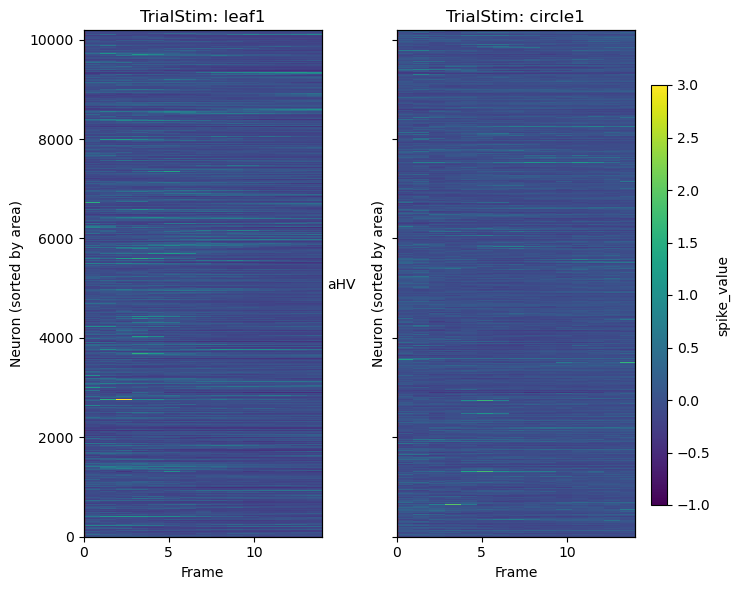

In [137]:
# Visualize the trial-stim averages 
plot_trialstim_heatmaps(melted_spikes_start, save=True, name=which_tex+'_at_trial_start_'+area)

## Select frames at sound cue

In [138]:
# Ensure we extract segments for EVERY trial, even near trial bounds (where frames before/after might be missing).
# Vectorized implementation using reindexing around the anchor index per trial (faster, less Python looping).

assert 'merged_df' in globals(), "merged_df must exist before segmenting."

num_frames_before = 10
num_frames_after = 10
include_soundpos_frame = True

# Determine a time-like reference column and trial index column
time_ref_col = None
for col_option in ['time', 'ft']:
    if col_option in merged_df.columns:
        time_ref_col = col_option
        break
assert time_ref_col is not None, "No valid time reference column found in merged_df."

if 'trInd' in merged_df.columns:
    trial_index_column = 'trInd'
elif 'ft_trInd' in merged_df.columns:
    trial_index_column = 'ft_trInd'
else:
    raise KeyError("Neither 'trInd' nor 'ft_trInd' found in merged_df.")

if 'SoundPos' not in merged_df.columns:
    raise KeyError("'SoundPos' not found in merged_df.")
if 'ft_Pos' not in merged_df.columns:
    raise KeyError("'ft_Pos' not found in merged_df.")

# Sort to guarantee chronological order within each trial
merged_df_sorted = merged_df.sort_values([trial_index_column, time_ref_col])

# Build the relative index window to reindex against
if include_soundpos_frame:
    relative_idxs = np.arange(-num_frames_before, num_frames_after + 1)
else:
    relative_idxs = np.concatenate([
        np.arange(-num_frames_before, 0),
        np.arange(1, num_frames_after + 1)
    ])

segments = []
for tid, trial_df in merged_df_sorted.groupby(trial_index_column, sort=False):
    trial_df = trial_df.reset_index(drop=True)
    if not trial_df['SoundPos'].notnull().any():
        continue

    # Anchor on the cue position within this trial
    sound_pos_value = float(trial_df['SoundPos'].dropna().iloc[0])
    ft_pos = trial_df['ft_Pos'].to_numpy()

    # Exact match or nearest BEFORE; if none before, nearest overall
    exact_mask = np.isclose(ft_pos, sound_pos_value, rtol=0.0, atol=1e-8)
    if exact_mask.any():
        anchor_idx = int(np.argmax(exact_mask))
    else:
        prior_mask = ft_pos <= sound_pos_value
        if prior_mask.any():
            anchor_idx = int(np.max(np.where(prior_mask)[0]))  # nearest before
        else:
            anchor_idx = int(np.argmin(np.abs(ft_pos - sound_pos_value)))  # nearest overall

    # Reindex by desired relative frames around the anchor; out-of-bounds become NaN rows
    trial_rel = trial_df.copy()
    trial_rel.index = np.arange(len(trial_rel)) - anchor_idx
    segment = trial_rel.reindex(relative_idxs).copy()

    # Ensure trial id and SoundPos are filled for padded rows without triggering FutureWarning
    # Fill trial index
    if segment[trial_index_column].dtype == 'O':
        segment[trial_index_column] = pd.to_numeric(segment[trial_index_column], errors='coerce')
    segment.loc[segment[trial_index_column].isna(), trial_index_column] = tid

    # Fill SoundPos safely
    if segment['SoundPos'].dtype == 'O':
        segment['SoundPos'] = pd.to_numeric(segment['SoundPos'], errors='coerce')
    segment.loc[segment['SoundPos'].isna(), 'SoundPos'] = sound_pos_value

    # Add relative frame index
    segment['frame'] = relative_idxs
    segments.append(segment)

# Concatenate all segments into a single DataFrame
segmented_df_cue_pos = pd.concat(segments, axis=0, ignore_index=True) if segments else pd.DataFrame()

segmented_df_cue_pos

,ft,ft_trInd,ft_trInd_odd,ft_trInd_even,ft_PosCum,ft_Pos,ft_move,ft_isMoving,ft_GraySpc,ft_CorrSpc,ft_WallID,ft_RunCum,ft_RunSpeed,RunFr,BefCueFr,AftCueFr,datetime,time,trInd,trInd_odd,trInd_even,Trial_start_time,Trial_end_time,Gray_space_time,SoundPos,SoundTime,SoundTimeDelay,RewTime,RewPos,isRew,WallType,WallIsProbe,WallName,RewardFr,StartFr,GrayFr,EndFr,SoundFr,SoundDelayFr,SoundDelPos,...,59219,59223,59231,59236,59237,59238,59247,59248,59253,59258,59260,59262,59263,59265,59266,59268,59270,59272,59275,59277,59278,59283,59285,59287,59288,59290,59291,59294,59295,59296,59300,59302,59308,59312,59316,59317,59318,59322,59330,frame
0,738252.498505,0.0,True,False,7.600000,7.600000,1.600000,True,False,True,leaf1,45.294724,22.286081,7.189058,True,False,2021-04-06 11:57:50.834506671,4.417649,0.0,True,False,738252.498471,738252.49871,738252.498659,18.800000,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,...,-1.058255,0.356644,1.140671,0.098437,0.571659,1.632042,0.826694,1.166359,0.548636,5.582910,0.032423,-0.218389,-0.399624,4.704719,3.005028,2.191319,1.587177,0.417060,-0.928640,0.782921,-0.068640,2.604350,0.980694,-0.565077,0.827669,2.684605,1.672258,0.641210,-0.634598,-0.614453,-0.918908,1.551220,1.578827,2.823706,3.392923,3.213320,1.110879,0.934613,1.272544,-10
1,738252.498509,0.0,True,False,7.600000,7.600000,0.000000,False,False,True,leaf1,47.459957,6.712224,2.203584,True,False,2021-04-06 11:57:51.136355776,4.719498,0.0,True,False,738252.498471,738252.49871,738252.498659,18.800000,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,...,-0.187001,1.229878,1.055367,2.799377,-0.656341,4.068325,2.544726,0.081639,0.401249,2.981311,-0.637042,1.936368,-1.302445,1.385645,2.223953,1.138135,0.782513,-1.124388,-0.787009,1.053262,0.628444,2.003714,0.319310,0.729120,1.215033,0.512181,-0.616558,-0.242102,1.965973,-0.409412,-0.612415,-0.106396,1.019240,2.482264,0.309451,1.841364,-0.223729,-0.579859,-1.072202,-9
2,738252.498512,0.0,True,False,7.600000,7.600000,0.000000,False,False,True,leaf1,49.181507,5.336804,1.721550,True,False,2021-04-06 11:57:51.459588777,5.042731,0.0,True,False,738252.498471,738252.49871,738252.498659,18.800000,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,...,-0.391591,0.986270,2.457527,1.132464,-1.038038,2.689942,1.571901,-0.538828,-0.076480,1.632002,-0.771224,0.952017,0.050983,-1.138261,2.630302,0.815862,1.062251,0.706638,-1.640592,-0.104488,-0.562286,0.935429,1.406911,3.646307,0.370702,0.223689,-1.080729,-0.283534,0.132138,-0.595343,-0.245211,2.161191,2.704782,0.957021,0.207875,-0.011536,-1.283287,-0.491601,0.129081,-8
3,738252.498516,0.0,True,False,8.248834,8.248834,0.648834,True,False,True,leaf1,53.487041,13.347157,4.305534,True,False,2021-04-06 11:57:51.776374429,5.359516,0.0,True,False,738252.498471,738252.49871,738252.498659,18.800000,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,...,2.284918,-0.748121,4.213337,0.399692,0.232170,0.709118,2.428825,1.980502,6.923430,0.986128,0.059107,5.654955,3.006986,-0.712038,3.636842,0.274504,-1.129120,0.197571,0.284222,3.501872,0.213413,3.518674,4.868231,-0.483188,-0.569127,-0.319020,-1.114399,-0.409797,0.956517,-0.794140,-0.850610,0.336388,-0.380750,0.895003,1.896118,3.391943,1.186990,0.999617,1.405913,-7
4,738252.498519,0.0,True,False,9.800000,9.800000,1.551166,True,False,True,leaf1,60.073462,20.417906,6.586421,True,False,2021-04-06 11:57:52.084057331,5.667199,0.0,True,False,738252.498471,738252.49871,738252.498659,18.800000,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.21245,4.302538,56.339587,70.138628,24.21245,24.21245,18.833322,...,-1.075875,4.179021,6.354907,-1.150188,-0.271171,1.834918,1.709767,2.352802,0.568887,0.262093,-1.165002,4.249762,

In [139]:
len(segmented_df_cue_pos['trInd'].unique())

470

In [140]:
# 1. Determine the trial index column (idx_col)
if 'trInd' in segmented_df_cue_pos.columns:
    idx_col = 'trInd'
elif 'ft_trInd' in segmented_df_cue_pos.columns:
    idx_col = 'ft_trInd'
else:
    raise KeyError("Neither 'trInd' nor 'ft_trInd' found in segmented_df_cue_pos.")

# 2. Identify Spike Columns (spike_cols)
# Prioritize the robust method: intersection with spikes_df columns
spike_cols = [c for c in segmented_df_cue_pos.columns if c in spikes_df.columns]

if not spike_cols:
    # Fallback: Heuristically treat numeric columns not in meta as spikes
    # Use a set for O(1) average time complexity lookups in the loop
    meta_cols = {'frame', idx_col, 'TrialStim', 'ft', 'time', 'ft_Pos', 'SoundPos', 'ft_CorrSpc'}
    
    # Use selected_dtypes and check for inclusion efficiently
    numeric_cols = segmented_df_cue_pos.select_dtypes(include=[np.number]).columns
    spike_cols = [c for c in numeric_cols if c not in meta_cols]

# 3. Define all ID variables (the columns that will NOT be melted)
id_vars = ['frame', idx_col, 'TrialStim']

# 4. Filter, Select, and Melt in a single, chained operation
# This minimizes the creation of large intermediate DataFrames.

# First, filter to keep rows with defined TrialStim only
# Use .loc[<condition>, <columns>] to select only the necessary columns
# The result of this slice is generally a view or a copy, but chaining melt 
# immediately after avoids explicitly saving a huge intermediate DF.
melted_spikes_cue_pos = (
    segmented_df_cue_pos.loc[
        segmented_df_cue_pos['TrialStim'].notna(), 
        id_vars + spike_cols # Select ONLY the required columns
    ]
    .melt(
        id_vars=id_vars,
        value_vars=spike_cols,
        var_name='neuron',
        value_name='spike_value'
    )
)
# 5. Optional: Normalize neuron dtype to numeric when possible
try:
    # If possible, convert to a memory-efficient integer type
    melted_spikes_cue_pos['neuron'] = melted_spikes_cue_pos['neuron'].astype('Int32') 
except Exception:
    pass

In [141]:
# Label areas 
#melted_spikes_cue_pos = add_area_label_to_melted_spikes(melted_spikes_cue_pos, root, recording_name=which)
melted_spikes_cue_pos['area'] = area
# melted_spikes_cue_pos.to_csv("data/segmented/melted_spikes_cue_pos.csv", index=False)

In [142]:
melted_spikes_cue_pos

,frame,trInd,TrialStim,neuron,spike_value,area
0,-10,0.0,leaf1,11042,0.387663,aHV
1,-9,0.0,leaf1,11042,-0.113128,aHV
2,-8,0.0,leaf1,11042,-0.559488,aHV
3,-7,0.0,leaf1,11042,1.263013,aHV
4,-6,0.0,leaf1,11042,0.493582,aHV
...,...,...,...,...,...,...
92538703,6,469.0,circle1,59330,-0.404608,aHV
92538704,7,469.0,circle1,59330,-0.113218,aHV
92538705,8,469.0,circle1,59330,0.152728,aHV
92538706,9,469.0,circle1,59330,-0.009391,aHV


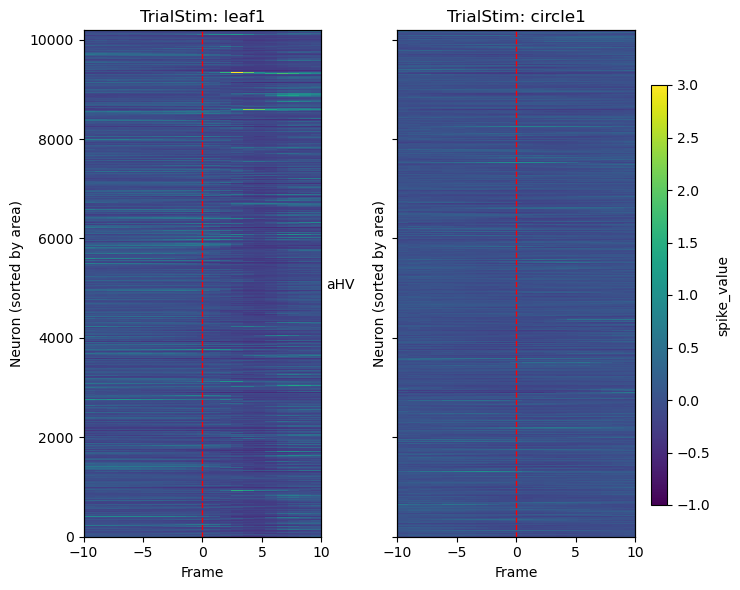

In [143]:
# Example usage (keeps prior behavior):
plot_trialstim_heatmaps(melted_spikes_cue_pos, save=True, name=which_tex+'_at_cue_pos_'+area)

In [144]:
# import numpy as np
# arr = melted_spikes_cue_pos.to_records(index=False)  # structured array
# np.save("data/segmented/melted_spikes_cue_pos.npy", arr)  # no compression
# or compressed:
# np.savez_compressed("data/segmented/melted_spikes_cue_pos.npz", data=arr)
df.columns

Index(['frame', 'ft_trInd', 'TrialStim', 'neuron', 'spike_value', 'area'], dtype='object')

In [145]:
melted_spikes_cue_pos.area

0           aHV
1           aHV
2           aHV
3           aHV
4           aHV
           ... 
92538703    aHV
92538704    aHV
92538705    aHV
92538706    aHV
92538707    aHV
Name: area, Length: 92538708, dtype: object

# Tensor decomposition 
Using TensorTools is a bare bones Python package for fitting and visualizing canonical polyadic (CP) tensor decompositions of higher-order data arrays. I originally developed this library for applications in neuroscience [(Williams et al., 2018)](https://doi.org/10.1016/j.neuron.2018.05.015), but the code could be helpful in other domains. https://github.com/ahwillia/tensortools/tree/main 

- **Note:** For usability purpose, the data subset is first stored as tensors in .npy format and loaded afterwards for decomposition

In [146]:
# SciPy compatibility shim for TensorTools (fixes AttributeError: scipy has no attribute 'random')
import numpy as np
import scipy
import types
import pandas as pd
import tensortools as tt

# SciPy compatibility shim for TensorTools (fixes AttributeError: scipy has no attribute 'random')
# TensorTools is a bare bones Python package uses and old version of scipy that includes a random module
# that is not compatible with the latest version of scipy.
if not hasattr(scipy, 'random'):
    scipy.random = types.SimpleNamespace(
        rand=np.random.rand,
        randint=np.random.randint,
        randn=np.random.randn,
        random=np.random.random,
        seed=np.random.seed,
        RandomState=np.random.RandomState,
        permutation=np.random.permutation,
        shuffle=np.random.shuffle,
    )
import os
# 1) Build tensor via memmap (avoid pivot to limit peak memory)
# Use the full dataset
df = melted_spikes_start[melted_spikes_start['area'] == area] # if you want to subset to a specific area at start
#df = melted_spikes_cue_pos#[melted_spikes_cue_pos['area'] == 'aHV'] # if you want to subset to a specific area at cue onset

# Keep only needed columns (no copy); factorize to 0-based contiguous indices
# Factorize does not aggregate; if duplicates exist, later entries overwrite earlier ones
neuron_codes, neuron_uniques = pd.factorize(df['neuron'], sort=False)
frame_codes, frame_uniques = pd.factorize(df['frame'], sort=False)
trial_codes, trial_uniques = pd.factorize(df['ft_trInd'], sort=False)

n_neurons = neuron_uniques.size
n_time = frame_uniques.size
n_trials = trial_uniques.size

from numpy.lib.format import open_memmap
# Derive dataset id from the spike file name (e.g., 'VR2_2021_03_20_1_SVD_dec.npy' -> 'VR2_2021_03_20_1')
dataset_id = os.path.basename(spike_file).replace('_SVD_dec.npy', '')

# Map back to which label you used (sup_bef, sup_aft, unsup_bef, unsup_aft)
candidates = {
    "sup_bef": sup_bef,
    "sup_aft": sup_aft,
    "unsup_bef": unsup_bef,
    "unsup_aft": unsup_aft,
}
dataset_label = next((k for k, v in candidates.items() if v == dataset_id), "unknown")

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

# Build a descriptive filename, e.g.:
# ensemble_sup_bef_VR2_2021_03_20_1_cp_als_r1-9_rep4.pkl
frame_start = frame_uniques.min()
frame_end = frame_uniques.max()
fname = (
    f"tensor_file_frames_{frame_start}_to_{frame_end}_{dataset_label}_{dataset_id}.npy"
)
memmap_path = os.path.join(save_dir, fname)

# memmap_path = '/Users/johnmadrid/GitHub/isp-unsupervised-learning/results/supervised_cue_onset_spikes_tensor_float32.npy'

# Create disk-backed array and zero-fill missing combos
tensor_mm = open_memmap(memmap_path, mode='w+', dtype=np.float32, shape=(n_neurons, n_time, n_trials))
tensor_mm[...] = 0.0

# Vectorized scatter into the memmap-backed tensor
vals = df['spike_value'].to_numpy(dtype=np.float32, copy=False)
tensor_mm[neuron_codes, frame_codes, trial_codes] = vals

# Expose as `tensor` for downstream use
tensor = tensor_mm

In [147]:
# Use the exact factorization order used to build the tensor
neuron_order = np.asarray(neuron_uniques)
frame_order = np.asarray(frame_uniques)
trial_order = np.asarray(trial_uniques, dtype=int)

# Optional: small shim so downstream code that expects `pivot` still works
pivot = types.SimpleNamespace( index=pd.Index(neuron_order), columns=pd.MultiIndex.from_product([frame_order, trial_order]))

In [ ]:


def _as_2d_regressor(z, n_trials, n_time, name="z"):
    z = np.asarray(z)
    if z.ndim == 1:
        if z.shape[0] != n_trials:
            raise ValueError(f"{name} has shape {z.shape}, expected ({n_trials},) or ({n_trials},{n_time})")
        return np.repeat(z[:, None], n_time, axis=1)  # (trials, time)
    if z.ndim == 2:
        if z.shape != (n_trials, n_time):
            raise ValueError(f"{name} has shape {z.shape}, expected ({n_trials},{n_time})")
        return z
    raise ValueError(f"{name} must be 1d or 2d")

def residualize_tensor_linear(X, covariates, add_intercept=True):
    """
    Residualize X (trials, neurons, time) against covariates.

    covariates: dict name -> array of shape (trials,) or (trials,time)
    Returns X_res with same shape as X.

    Model per neuron-time: X[:, n, t] = beta0 + sum_j beta_j * cov_j[:, t] + eps
    """
    X = np.asarray(X, dtype=float)
    T, N, K = X.shape

    # build design matrix per time: Z_t is (T, P)
    Z_list = []
    for name, z in covariates.items():
        Z_list.append(_as_2d_regressor(z, T, K, name=name))  # (T,K)

    P = len(Z_list) + (1 if add_intercept else 0)
    X_res = np.empty_like(X)

    # solve independently for each time bin (fast + transparent)
    for t in range(K):
        cols = []
        if add_intercept:
            cols.append(np.ones((T, 1)))
        for Zj in Z_list:
            cols.append(Zj[:, t:t+1])  # (T,1)
        Zt = np.concatenate(cols, axis=1)  # (T,P)

        # coefficients: (P,N) via least squares
        # X[:, :, t] is (T,N)
        beta, *_ = np.linalg.lstsq(Zt, X[:, :, t], rcond=None)
        pred = Zt @ beta  # (T,N)
        X_res[:, :, t] = X[:, :, t] - pred

    return X_res

Rank-1 models:  min obj, 0.95;  max obj, 0.95;  time to fit, 26.4s


Rank-2 models:  min obj, 0.93;  max obj, 0.93;  time to fit, 69.7s


Rank-3 models:  min obj, 0.91;  max obj, 0.91;  time to fit, 128.8s


Rank-4 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 231.3s


Rank-5 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 190.7s


Rank-6 models:  min obj, 0.87;  max obj, 0.87;  time to fit, 147.3s


Rank-7 models:  min obj, 0.86;  max obj, 0.86;  time to fit, 271.0s


Rank-8 models:  min obj, 0.86;  max obj, 0.86;  time to fit, 236.1s


Rank-9 models:  min obj, 0.85;  max obj, 0.85;  time to fit, 221.7s


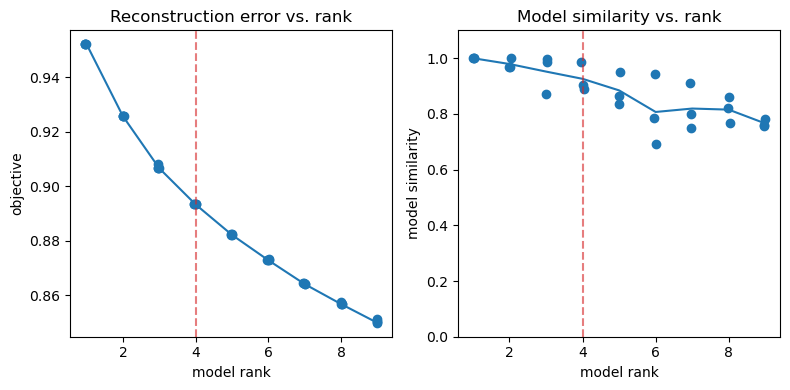

Selected best_rank = 4 (elbow on reconstruction error)


In [148]:
# 2) Rank sweep to select optimal number of components (K) before decomposition
import matplotlib.pyplot as plt

rank_range = range(1, 10)  # evaluate ranks 1..9 (adjust as needed)
replicates = 4

# Option 1: The method "cp_als" fits a unconstrained tensor decomposition
ensemble_rank_sweep = tt.Ensemble(fit_method="cp_als")

# Option 2: The method "ncp_hals" fits a nonnegative tensor decomposition
# ensemble_rank_sweep = tt.Ensemble(fit_method="ncp_hals")
#### Remove mean over trials 
tensor_c = tensor - tensor.mean(axis=2, keepdims=True) ###

#### Compute residual activity
#### TO DO: properly define speed_trial_time as (trials, time) with entry the speed
tensor_res = residualize_tensor_linear( tensor_c, covariates={"speed": speed_trial_time})

ensemble_rank_sweep.fit(tensor_res, ranks=rank_range, replicates=replicates)

# Plot reconstruction error and model similarity
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
tt.plot_objective(ensemble_rank_sweep, ax=axes[0])
tt.plot_similarity(ensemble_rank_sweep, ax=axes[1])
axes[0].set_title('Reconstruction error vs. rank')
axes[1].set_title('Model similarity vs. rank')
fig.tight_layout()

# Compute mean reconstruction error across replicates for each rank
orig_norm = np.linalg.norm(tensor_res)
mean_errors = []
best_rep_idx = {}
for r in rank_range:
    reps = ensemble_rank_sweep.factors(r)
    errs = []
    best_idx = 0
    best_err = None
    for i, (U, V, W) in enumerate(reps):
        # TensorTools returns factors shaped (mode_dim, rank). Reconstruct accordingly.
        if U.shape[0] == tensor_res.shape[0] and V.shape[0] == tensor_res.shape[1] and W.shape[0] == tensor_res.shape[2]:
            Xhat = np.einsum('ir,jr,kr->ijk', U, V, W)
        elif U.shape[1] == tensor_res.shape[0] and V.shape[1] == tensor_res.shape[1] and W.shape[1] == tensor_res.shape[2]:
            # Factors are (rank, mode_dim)
            Xhat = np.einsum('ri,rj,rk->ijk', U, V, W)
        else:
            raise ValueError(f"Unexpected factor shapes for rank {r}: {[a.shape for a in (U,V,W)]}")
        err = np.linalg.norm(tensor_res - Xhat) / (orig_norm + 1e-12)
        errs.append(err)
        if best_err is None or err < best_err:
            best_err = err
            best_idx = i
    mean_errors.append(float(np.mean(errs)))
    best_rep_idx[int(r)] = int(best_idx)

# Simple elbow heuristic on the error curve to suggest best_rank
x = np.arange(len(mean_errors), dtype=float) + 1.0  # ranks 1..N
y = np.array(mean_errors, dtype=float)

m = (y[-1] - y[0]) / (x[-1] - x[0] + 1e-12)
b = y[0] - m * x[0]
dist = np.abs(m * x + b - y) / (np.sqrt(m * m + 1.0) + 1e-12)
elbow_rank = int(x[np.argmax(dist)])

best_rank = int(max(1, elbow_rank))

# Visual cue on the plots
for ax in axes:
    ax.axvline(best_rank, color='tab:red', linestyle='--', alpha=0.6)
plt.show()

print(f"Selected best_rank = {best_rank} (elbow on reconstruction error)")

Save the results as pickle to avoid running model every time. Please update the frame start and end to the one used to calculate the decomposition.

In [149]:
# Save the results as pickle to avoid running model every time.
import os
import pickle

# Derive dataset id from the spike file name (e.g., 'VR2_2021_03_20_1_SVD_dec.npy' -> 'VR2_2021_03_20_1')
dataset_id = os.path.basename(spike_file).replace('_SVD_dec.npy', '')

# Map back to which label you used (sup_bef, sup_aft, unsup_bef, unsup_aft)
candidates = {
    "sup_bef": sup_bef,
    "sup_aft": sup_aft,
    "unsup_bef": unsup_bef,
    "unsup_aft": unsup_aft,
}
dataset_label = next((k for k, v in candidates.items() if v == dataset_id), "unknown")

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

# Build a descriptive filename, e.g.:
# ensemble_sup_bef_VR2_2021_03_20_1_cp_als_r1-9_rep4.pkl
frame_start = frame_uniques.min()
frame_end = frame_uniques.max()
fname = (
    f"ensemble_frames_{frame_start}_to_{frame_end}_{dataset_label}_{dataset_id}_"
    f"{ensemble_rank_sweep._fit_method.__name__}_"
    f"r{min(rank_range)}-{max(rank_range)}_rep{replicates}_area_{area}.pkl"
)
save_path = os.path.join(save_dir, fname)

# Save your payload as before
payload = {
    "ensemble": ensemble_rank_sweep,
    "best_rank": int(best_rank),
    "rank_range": list(rank_range),
    "replicates": int(replicates),
    "best_rep_idx": {int(k): int(v) for k, v in best_rep_idx.items()},
    "dataset_label": dataset_label,
    "dataset_id": dataset_id,
    "spike_file": spike_file,
    "beh_path": beh_path,
}

with open(save_path, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {save_path}")

# Load the results from pickle

# import pickle
# import tensortools as tt
# import matplotlib.pyplot as plt

# load_path = "/Users/johnmadrid/GitHub/isp-unsupervised-learning/results/ensemble_cp_als_r1-9_rep4.pkl"

# with open(load_path, "rb") as f:
#     data = pickle.load(f)

# ensemble_rank_sweep = data["ensemble"]
# best_rank = data.get("best_rank")
# best_rep_idx = data.get("best_rep_idx", {})

# # Plots
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# tt.plot_objective(ensemble_rank_sweep, ax=axes[0])
# tt.plot_similarity(ensemble_rank_sweep, ax=axes[1])
# axes[0].set_title("Reconstruction error vs. rank")
# axes[1].set_title("Model similarity vs. rank")
# fig.tight_layout()
# plt.show()

# # Factors (best replicate is index 0 by default)
# R = best_rank or 3
# rep_idx = best_rep_idx.get(R, 0)
# kt = ensemble_rank_sweep.factors(R)[rep_idx]
# U, V, W = kt[0], kt[1], kt[2]

Saved: results/ensemble_frames_0_to_14_sup_aft_VR2_2021_04_06_1_cp_als_r1-9_rep4_area_aHV.pkl


In [150]:
# 3) Final decomposition using the selected best_rank
R = int(best_rank)
rep_idx = int(best_rep_idx[R])

# Get the factors object directly (as returned by TensorTools)
factors = ensemble_rank_sweep.factors(R)[rep_idx]

/var/folders/ls/6ql6fg813sg3n0xtcm7pgvkw0000gn/T/ipykernel_79993/3769133041.py:53: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  sns.scatterplot(data=neu_df, x='neuron_idx', y='loading', hue='area', s=2, alpha=0.55,
/var/folders/ls/6ql6fg813sg3n0xtcm7pgvkw0000gn/T/ipykernel_79993/3769133041.py:53: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  sns.scatterplot(data=neu_df, x='neuron_idx', y='loading', hue='area', s=2, alpha=0.55,
/var/folders/ls/6ql6fg813sg3n0xtcm7pgvkw0000gn/T/ipykernel_79993/3769133041.py:53: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  sns.scatterplot(data=neu_df, x='neuron_idx', y='loading', hue='area', s=2, alpha=0.55,
/var/folders/ls/6ql6fg813sg3n0xtcm7pgvkw0000gn/T/ipykernel_79993/3769133041.py:53: UserWarning: The palette list has more values (6) than needed (1), which may not be intended.
  sns.scatterplot(data=ne

Plot saved to plots/tensor_components_grid_sup_aft_unconstraint_cp_als_aHV.pdf


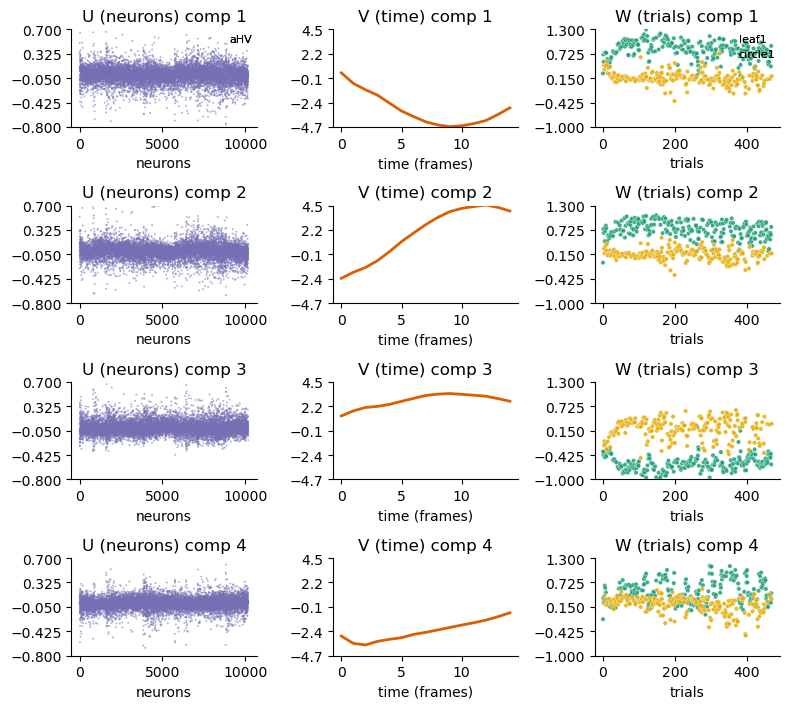

In [151]:
# Component-wise subplot grid like tt.plot_factors (scatter, line, scatter) using metadata
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
dark2_colors = sns.color_palette("Dark2")
# Unpack factors (mode_dim, rank) for neuron, time, trial
aU, aV, aW = factors  # shapes: (n_neurons, R), (n_time, R), (n_trials, R)
R = aU.shape[1]

# Recover ordering used in the tensor from pivot
neuron_order = pivot.index.to_numpy()
frame_labels = pivot.columns.get_level_values(0)
trial_labels = pivot.columns.get_level_values(1)
frame_order = pd.unique(frame_labels)
trial_order = pd.unique(trial_labels).astype(int)

# Metadata maps
neuron_to_area = (
    melted_spikes_start[['neuron', 'area']]
    .drop_duplicates()
    .set_index('neuron')['area']
)
trial_to_stim = (
    melted_spikes_start[['ft_trInd', 'TrialStim']]
    .dropna()
    .drop_duplicates(subset=['ft_trInd'])
    .set_index('ft_trInd')['TrialStim']
)

# Set figure height dynamically relative to number of rows
height_per_row = 2.2  # reasonable height per row (in inches)
fig_height =  1.8 * R #max(2.5, min(2.2 * R, 18))
fig, axes = plt.subplots(R, 3, figsize=(8, fig_height), sharex=False)
if R == 1:
    axes = np.array([axes])

# Global y-limits per column (neurons/time/trials)
u_min, u_max = round(float(np.nanmin(aU)), 1), round(float(np.nanmax(aU)), 1)
v_min, v_max = round(float(np.nanmin(aV)), 1), round(float(np.nanmax(aV)), 1)
w_min, w_max = round(float(np.nanmin(aW)), 1), round(float(np.nanmax(aW)), 1)

for k in range(R):
    # ---- Neuron scatter (colored by area): x = neuron index, y = loading ----
    ax0 = axes[k, 0]
    neu_df = pd.DataFrame({'neuron': neuron_order, 'loading': aU[:, k]})
    neu_df['area'] = neu_df['neuron'].map(neuron_to_area)
    # sort by area then neuron for a consistent order and build x index
    neu_df = neu_df.sort_values(['area', 'neuron']).reset_index(drop=True)
    neu_df['neuron_idx'] = np.arange(len(neu_df))
    sns.scatterplot(data=neu_df, x='neuron_idx', y='loading', hue='area', s=2, alpha=0.55, 
                    edgecolor='none',
                    palette=sns.color_palette("Dark2")[2:],
                    ax=ax0, legend=(k == 0))
    ax0.set_title(f'U (neurons) comp {k+1}')
    ax0.set_xlabel('neurons')
    ax0.set_ylabel('')
    ax0.set_ylim(u_min, u_max)
    ax0.set_yticks(np.linspace(u_min, u_max, num=5))
    sns.despine(ax=ax0, top=True, right=True)

    # ---- Time line: x = frame, y = loading ----
    ax1 = axes[k, 1]
    time_df = pd.DataFrame({'frame': frame_order, 'loading': aV[:, k]})
    sns.lineplot(data=time_df, x='frame', y='loading', ax=ax1, color=sns.color_palette("Dark2")[1], linewidth=2)
    ax1.set_title(f'V (time) comp {k+1}')
    ax1.set_xlabel('time (frames)')
    ax1.set_ylabel('')
    ax1.set_ylim(v_min, v_max)
    ax1.set_yticks(np.linspace(v_min, v_max, num=5))
    sns.despine(ax=ax1, top=True, right=True)

    # ---- Trials scatter (colored by TrialStim): x = ft_trInd, y = loading ----
    ax2 = axes[k, 2]
    tr_df = pd.DataFrame({'ft_trInd': trial_order, 'loading': aW[:, k]})
    tr_df['TrialStim'] = tr_df['ft_trInd'].map(trial_to_stim)
    custom_trialstim_palette = {'circle1': '#DFAE32', 'leaf1': '#02968a'}
    custom_trialstim_palette = {'circle1': dark2_colors[5], 'leaf1': dark2_colors[0]}
    sns.scatterplot(data=tr_df, x='ft_trInd', y='loading', hue='TrialStim', s=10, alpha=0.85,
                    ax=ax2, legend=(k == 0), palette=custom_trialstim_palette)
    ax2.set_title(f'W (trials) comp {k+1}')
    ax2.set_xlabel('trials')
    ax2.set_ylabel('')
    ax2.set_ylim(w_min, w_max)
    ax2.set_yticks(np.linspace(w_min, w_max, num=5))
    sns.despine(ax=ax2, top=True, right=True)

# Place legends nicely only once (first row)
if R >= 1:
    # Move neuron-area legend outside on top right
    leg0 = axes[0, 0].legend( fontsize=8, loc='upper right', borderaxespad=0.,frameon=False)
    if leg0 is not None:
        axes[0, 0].add_artist(leg0)
    # Move trial-stim legend outside on top right (account for grid col separation)
    leg2 = axes[0, 2].legend( fontsize=8, loc='upper right', borderaxespad=0.,frameon=False)
    if leg2 is not None:
        axes[0, 2].add_artist(leg2)

plt.tight_layout()

# Ensure results folder exists
results_dir = "results"
plots_dir = 'plots'
os.makedirs(results_dir, exist_ok=True)
plot_filename = os.path.join(plots_dir, f"tensor_components_grid_{which_tex}_unconstraint_cp_als_{area}.png")
plt.savefig(plot_filename, dpi=200)
plot_filename = os.path.join(plots_dir, f"tensor_components_grid_{which_tex}_unconstraint_cp_als_{area}.pdf")
plt.savefig(plot_filename, dpi=200)
print(f"Plot saved to {plot_filename}")

plt.show()

Compute the variance explained by each component

In [152]:
import numpy as np

# get the actual model for this rank/replicate

Xhat = factors.full()                               # correct reconstruction

sse = np.sum((tensor - Xhat)**2)
sst = np.sum(tensor**2)
ve = 1 - sse/sst
print("ve:", ve)

ve: 0.19149143359545473


In [153]:
#Total variance explained for that model

import numpy as np

def reconstruct_from_factors(aU, aV, aW, comps=None):
    """
    CP reconstruction: Xhat = sum_r aU[:,r] ∘ aV[:,r] ∘ aW[:,r]
    comps: iterable of component indices (0..R-1). If None, use all.
    """
    R = aU.shape[1]
    if comps is None:
        comps = range(R)

    Xhat = np.zeros((aU.shape[0], aV.shape[0], aW.shape[0]), dtype=float)
    for r in comps:
        Xhat += np.einsum("i,j,k->ijk", aU[:, r], aV[:, r], aW[:, r])
    return Xhat

def variance_explained_total(tensor, aU, aV, aW):
    X = np.asarray(tensor, dtype=float)
    Xhat = reconstruct_from_factors(aU, aV, aW)
    sse = np.sum((X - Xhat)**2)
    sst = np.sum(X**2)
    ve = 1.0 - sse / sst
    return float(ve), float(sse), float(sst)

ve, sse, sst = variance_explained_total(tensor, aU, aV, aW)
print("variance explained total:", ve)

variance explained total: 0.19149138796225185


Because CP components are not orthogonal, there isn’t a unique “variance explained by component r” like PCA. The most standard convention is incremental VE: how much adding component r improves reconstruction when you add components cumulatively in the current order.


In [154]:
def variance_explained_by_component_cumulative(tensor, aU, aV, aW):
    """
    Incremental and cumulative variance explained by each CP component when added in
    the current factor order (0, 1, ..., R-1).

    CP (CANDECOMP/PARAFAC) does NOT return components ordered by variance (unlike PCA).
    The solver (e.g. cp_als) returns components in fit/initialization order, so
    component 0 is not necessarily the "first" in terms of explained variance.

    Incremental VE = (VE after adding components 0..r) - (VE after 0..r-1).
    Because CP components are not orthogonal, adding a component can *increase* SSE
    (worsen reconstruction), so incremental VE can be negative. This happens when
    a component overlaps with already-added components or when a component used alone
    explains almost nothing / wrong direction (SSE > SST → VE < 0).

    Returns:
        ve_cum: cumulative VE after components 0..r (r = 0..R-1)
        ve_incr: incremental VE for component r (when added in current order)
        sse_cum: cumulative SSE after components 0..r
    """
    X = np.asarray(tensor, dtype=float)
    sst = np.sum(X**2)
    R = aU.shape[1]

    ve_cum = np.zeros(R, dtype=float)
    sse_cum = np.zeros(R, dtype=float)

    Xhat = np.zeros_like(X, dtype=float)
    for r in range(R):
        Xhat += np.einsum("i,j,k->ijk", aU[:, r], aV[:, r], aW[:, r])
        resid = X - Xhat
        sse_cum[r] = np.sum(resid**2)
        ve_cum[r] = 1.0 - sse_cum[r] / sst

    ve_incr = np.empty(R, dtype=float)
    ve_incr[0] = ve_cum[0]
    ve_incr[1:] = ve_cum[1:] - ve_cum[:-1]
    return ve_cum, ve_incr, sse_cum

In [155]:
ve_cum, ve_incr, sse_cum = variance_explained_by_component_cumulative(tensor, aU, aV, aW)

In [156]:
R = len(ve_cum)
df_ve = pd.DataFrame({
    "component": np.arange(R),
    "ve_incr": ve_incr,
    "ve_cum": ve_cum,
    "sse_cum": sse_cum,
})

# print nicely in the console
print(df_ve.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

# (optional) top components by incremental explained variance
print("\nTop components by ve_incr:")
print(df_ve.sort_values("ve_incr", ascending=False).head(10).to_string(index=False, float_format=lambda x: f"{x:.6g}"))

 component   ve_incr     ve_cum     sse_cum
         0 -0.306458  -0.306458 1.43694e+07
         1  0.293727 -0.0127313 1.11387e+07
         2  0.122505   0.109774 9.79134e+06
         3 0.0817174   0.191491 8.89255e+06

Top components by ve_incr:
 component   ve_incr     ve_cum     sse_cum
         1  0.293727 -0.0127313 1.11387e+07
         2  0.122505   0.109774 9.79134e+06
         3 0.0817174   0.191491 8.89255e+06
         0 -0.306458  -0.306458 1.43694e+07


**Why negative incremental VE?** CP components are not orthogonal. Your function adds components in index order (0, 1, 2, 3). So `ve_incr[r]` is the gain from adding component `r` *after* components 0..r-1. If component 0 is used *first*, its reconstruction alone can be worse than the baseline (SSE > SST → VE_cum[0] < 0). Adding component 1 then improves fit (positive ve_incr for component 1). So the negative value is for the component that happens to be in position 0, not because "variance" is negative in an absolute sense.

**PCA-like ordering:** To get components ordered by incremental VE (largest first) and nonnegative incremental VE when added in that order, reorder the factors by greedy incremental VE (see cell below).

In [ ]:
def reorder_factors_by_incremental_ve(tensor, aU, aV, aW):
    """
    Greedy ordering: at each step add the component that reduces SSE the most.
    Returns (aU_reord, aV_reord, aW_reord, order) so that when you compute
    variance_explained_by_component_cumulative(tensor, aU_reord, aV_reord, aW_reord),
    ve_incr is nonnegative and decreasing (PCA-like).
    """
    X = np.asarray(tensor, dtype=float)
    sst = np.sum(X**2)
    R = aU.shape[1]
    used = []
    Xhat = np.zeros_like(X, dtype=float)
    for _ in range(R):
        best_r = None
        best_sse = np.inf
        for r in range(R):
            if r in used:
                continue
            Xhat_try = Xhat + np.einsum("i,j,k->ijk", aU[:, r], aV[:, r], aW[:, r])
            sse = np.sum((X - Xhat_try) ** 2)
            if sse < best_sse:
                best_sse = sse
                best_r = r
        used.append(best_r)
        Xhat += np.einsum("i,j,k->ijk", aU[:, best_r], aV[:, best_r], aW[:, best_r])
    order = np.array(used)
    aU_reord = aU[:, order]
    aV_reord = aV[:, order]
    aW_reord = aW[:, order]
    return aU_reord, aV_reord, aW_reord, order

# Optional: reorder and recompute VE (PCA-like order, no negative incremental VE)
# aU, aV, aW, perm = reorder_factors_by_incremental_ve(tensor, aU, aV, aW)
# ve_cum, ve_incr, sse_cum = variance_explained_by_component_cumulative(tensor, aU, aV, aW)
# print("Component order (original index -> new position):", perm)
# print("Reordered ve_incr (should be nonnegative, decreasing):", ve_incr)

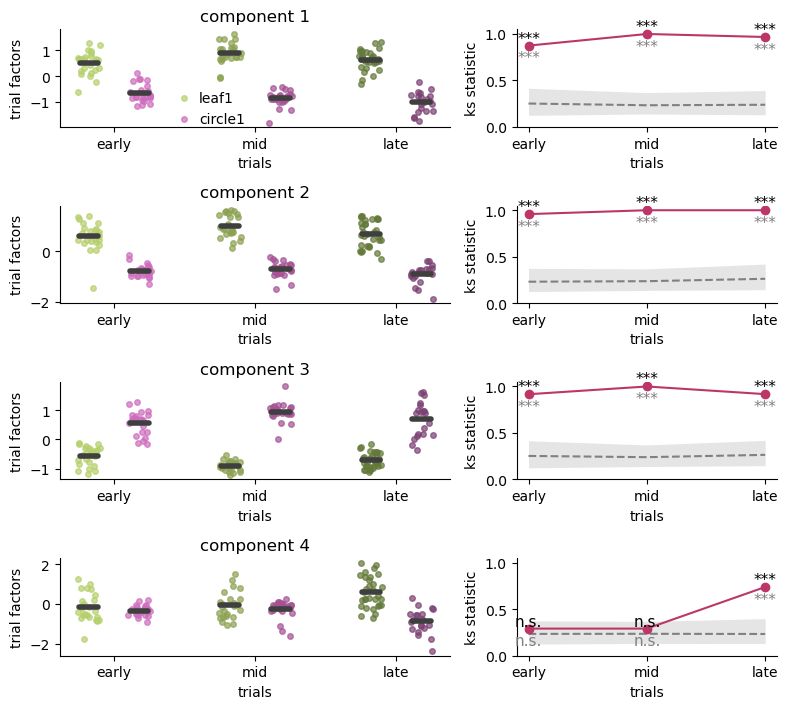

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore, ks_2samp

def p_to_stars(p):
    if not np.isfinite(p):
        return ""
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."

# 
tab20 = plt.get_cmap("tab20b")
stim_color = {
    'leaf1': [tab20(6),tab20(5),tab20(4)] ,  # e.g. blue-ish
    'circle1': [tab20(18),tab20(17),tab20(16)] ,   # e.g. orange-ish
}



from scipy.stats import ks_2samp
#### function for running permutaiot tests

def perm_pvalue_ks_stratified(x, labels, t, stim1, stim2, B=5000, n_bins=5, rng=None):
    """
    x: values in the window (1d)
    labels: stimulus labels for those values (1d, strings)
    t: trial indices for those values (1d, numeric) used to define bins
    Shuffles labels within time bins, recomputes KS statistic.
    Returns (D_obs, p_perm, null).
    """
    if rng is None:
        rng = np.random.default_rng(0)

    x = np.asarray(x)
    labels = np.asarray(labels)
    t = np.asarray(t)

    # observed KS
    x1 = x[labels == stim1]
    x2 = x[labels == stim2]
    D_obs = ks_2samp(x1, x2, alternative="two-sided", mode="auto").statistic

    # define bins by sorting by time
    order = np.argsort(t)
    bins = np.array_split(order, n_bins)

    null = np.empty(B, dtype=float)
    for b in range(B):
        lab_perm = labels.copy()
        for idx in bins:
            lab_perm[idx] = rng.permutation(lab_perm[idx])

        xb1 = x[lab_perm == stim1]
        xb2 = x[lab_perm == stim2]
        null[b] = ks_2samp(xb1, xb2, alternative="two-sided", mode="auto").statistic

    p_perm = (1.0 + np.sum(null >= D_obs)) / (B + 1.0)
    return float(D_obs), float(p_perm), null


def ks_window_analysis_and_plot(
    aW,
    trial_order,
    trial_to_stim,
    stims=("leaf1", "circle1"),
    # non-overlapping windows (inclusive indices)
    windows=None,
    components=None,
    max_rows=4,
    window_size_check=True,
    random_seed=0,
):
    """
    For each TCA component k:
      1) z-score trial factors (across all trials for that component)
      2) split into windows
      3) build two distributions per window by stimulus
      4) two-sample KS test per window (stim1 vs stim2)
    Then plot: 4 rows x 2 cols (left: strip+means; right: KS statistic).

    Parameters
    ----------
    aW : array, shape (n_trials, R)
        Trial factor matrix (TCA weights over trials).
    trial_order : array-like, shape (n_trials,)
        Trial indices (ft_trInd values).
    trial_to_stim : dict or pd.Series
        Mapping from trial index -> stimulus label (e.g., 'leaf1', 'circle1').
    stims : tuple(str, str)
        The two stimulus labels to compare.
    windows : dict[str, tuple(int, int)]
        Window name -> (start_trial_index, end_trial_index), inclusive.
        These are in ft_trInd coordinates (i.e., your trial indices).
    components : list[int] or None
        Component indices (0-based). If None, uses all components.
    max_rows : int
        Plot up to this many components (rows). Default 4 for 8 subplots.
    """

    rng = np.random.default_rng(random_seed)
    aW = np.asarray(aW)
    n_trials, R = aW.shape

    if windows is None:
        windows = {
            "early": (0, 49),
            "mid": (n_trials//2 - 25, n_trials//2 + 25),
            "late": (n_trials-51, n_trials-1),
        }

    

    if components is None:
        components = list(range(R))
    else:
        components = list(components)

    # we'll plot up to max_rows components; still compute all if you want
    plot_components = components[: min(len(components), max_rows)]

    # build base dataframe with ft_trInd + TrialStim once
    base_df = pd.DataFrame({"ft_trInd": np.asarray(trial_order)})
    base_df["TrialStim"] = base_df["ft_trInd"].map(trial_to_stim)

    # optional sanity checks for non-overlap + size
    if window_size_check:
        # check overlap in ft_trInd coordinates
        spans = [(name, w[0], w[1]) for name, w in windows.items()]
        spans_sorted = sorted(spans, key=lambda x: x[1])
        for (n1, a1, b1), (n2, a2, b2) in zip(spans_sorted[:-1], spans_sorted[1:]):
            if a2 <= b1:
                raise ValueError(f"windows overlap: '{n1}' [{a1},{b1}] and '{n2}' [{a2},{b2}]")

    results_rows = []
    dist_rows = []  # long-form values for plotting strip plots

    # precompute window masks on ft_trInd
    ft = base_df["ft_trInd"].to_numpy()
    win_masks = {wname: (ft >= a) & (ft <= b) for wname, (a, b) in windows.items()}

    stim1, stim2 = stims

    for k in components:
        # z-score across all trials for this component
        loading_z = zscore(aW[:, k], nan_policy="omit")
        dfk = base_df.copy()
        dfk["loading_z"] = loading_z

        for wname, mask in win_masks.items():
            dfw = dfk.loc[mask & dfk["TrialStim"].isin(stims), ["ft_trInd","loading_z", "TrialStim"]].dropna()

            x = dfw["loading_z"].to_numpy()
            labels = dfw["TrialStim"].to_numpy()
            t = dfw["ft_trInd"].to_numpy()

            
            x1 = dfw.loc[dfw["TrialStim"] == stim1, "loading_z"].to_numpy()
            x2 = dfw.loc[dfw["TrialStim"] == stim2, "loading_z"].to_numpy()

            # record distributions for plotting
            for stim_lbl, arr in [(stim1, x1), (stim2, x2)]:
                if arr.size:
                    dist_rows.append( pd.DataFrame( { "component": k, "window": wname,  "stim": stim_lbl, "value": arr,}) )

            # KS test asymtotic - checking for too-small samples
            if (x1.size >= 2) and (x2.size >= 2):
                ks = ks_2samp(x1, x2, alternative="two-sided", mode="auto")
                stat = float(ks.statistic)
                pval_asympt = float(ks.pvalue) ### assymptotic pval from kS test
                n1, n2 = int(x1.size), int(x2.size)

                # stratified permutation p-value (robust to within-window trend)
                D_obs, p_perm, null = perm_pvalue_ks_stratified(
                    x=x, labels=labels, t=t,
                    stim1=stim1, stim2=stim2,
                    B=1000, n_bins=5, rng=rng)
                
                null_mean = float(np.mean(null))
                null_median = float(np.median(null))
                null_q05 = float(np.quantile(null, 0.05))
                null_q95 = float(np.quantile(null, 0.95))
                
            else:
                stat, pval_asympt, p_perm = np.nan, np.nan, np.nan
                n1, n2 = int(x1.size), int(x2.size)

            results_rows.append(
                {
                    "component": k,
                    "window": wname,
                    "ks_stat": stat,
                    "p_value_asympt": pval_asympt,
                    "p_perm": p_perm, 
                    "ks_null_mean": null_mean,
                    "ks_null_median": null_median,
                    "ks_null_q05": null_q05,
                    "ks_null_q95": null_q95,
                    "n_stim1": n1,
                    "n_stim2": n2,
                }
            )

    results_df = pd.DataFrame(results_rows)
    dist_df = pd.concat(dist_rows, ignore_index=True) if dist_rows else pd.DataFrame(
        columns=["component", "window", "stim", "value"]
    )

    # -------- plotting (4 rows x 2 cols) --------
    nrows = len(plot_components)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=2,
        figsize=(8, 1.8 * nrows),
        sharex=False,
        sharey=False,
        gridspec_kw={"width_ratios": [3., 2]},
    )

    if nrows == 1:
        axes = np.array([axes])  # make it 2d-like for consistent indexing

    window_order = list(windows.keys())
    x_base = np.arange(len(window_order))

    # offsets for the two stimuli within each window on the strip plot
    offsets = {stim1: -0.18, stim2: +0.18}

    for r, k in enumerate(plot_components):
        axL = axes[r, 0]
        axR = axes[r, 1]

        # ---- left: strip plot + means ----
        sub = dist_df[dist_df["component"] == k].copy()

        # vertical reference: x ticks at window categories
        axL.set_xticks(x_base)
        axL.set_xticklabels(window_order)
        axL.set_xlabel("trials")
        axL.set_ylabel("trial factors")
        axL.set_title(f"component {k+1}")

        # draw strip + means
        for wi, wname in enumerate(window_order):
            for stim_lbl in stims:
                vals = sub[(sub["window"] == wname) & (sub["stim"] == stim_lbl)]["value"].to_numpy()

                if vals.size == 0:
                    continue

                x0 = wi + offsets[stim_lbl]
                c = stim_color[stim_lbl][wi]
                # jitter around x0
                jitter = rng.uniform(-0.08, 0.08, size=vals.size)
                axL.scatter(x0 + jitter,  vals, s=16, alpha=0.7, color=c,
                    label=stim_lbl if (wi == 0) else None,  # legend once per row
                )

                # mean bar
                m = float(np.mean(vals))
                axL.plot([x0 - 0.065, x0 + 0.065], [m, m], linewidth=4,c='#3f3f3f',zorder=100, solid_capstyle='round')

        axL.spines["top"].set_visible(False)
        axL.spines["right"].set_visible(False)
        if r==0:
            axL.legend(frameon=False, loc=2, bbox_to_anchor=(0.25, 0.5), handletextpad=0.1)

        # ---- right: KS statistic per window ----
        resk = results_df[results_df["component"] == k].set_index("window")
        ks_vals = np.array([resk.loc[w, "ks_stat"] if w in resk.index else np.nan for w in window_order], dtype=float)
        p_vals = np.array([resk.loc[w, "p_value_asympt"] if w in resk.index else np.nan for w in window_order], dtype=float)
        p_vals_perm = np.array([resk.loc[w, "p_perm"] if w in resk.index else np.nan for w in window_order], dtype=float)
        null_mean = np.array([resk.loc[w, "ks_null_mean"] for w in window_order], dtype=float)
        null_q05 = np.array([resk.loc[w, "ks_null_q05"] for w in window_order], dtype=float)
        null_q95 = np.array([resk.loc[w, "ks_null_q95"] for w in window_order], dtype=float)

        
        axR.fill_between(x_base, null_q05, null_q95, alpha=0.2, linewidth=0, color='grey') 
        axR.plot(x_base, null_mean, linestyle="--", linewidth=1.5, label="null", c='grey')

        axR.plot(x_base, ks_vals, marker="o",c='#bc3768')
        axR.set_xticks(x_base)
        axR.set_xticklabels(window_order)
        axR.set_ylim(0, 1.05)
        axR.set_xlabel("trials")
        axR.set_ylabel("ks statistic")
        #axR.set_title(f"component {k}: ks test ({stim1} vs {stim2})")

        # annotate p-values (compact)
        # annotate significance with stars
        for wi, (stat, pv) in enumerate(zip(ks_vals, p_vals)):
            if np.isfinite(stat) and np.isfinite(pv):
                stars = p_to_stars(pv)
                axR.text( wi, stat, stars,  va="bottom", ha="center",
                    fontsize=11,)
        for wi, (stat, pv) in enumerate(zip(ks_vals, p_vals_perm)):
            if np.isfinite(stat) and np.isfinite(pv):
                stars = p_to_stars(pv)
                axR.text( wi, stat-0.05, stars,  va="top", ha="center",
                    fontsize=11,color='grey')

        axR.spines["top"].set_visible(False)
        axR.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(str(base) + '/plots/' + which_tex + area +'_KS_result.pdf', dpi=200)
    plt.savefig(str(base) + '/plots/' + which_tex + area +'_KS_result.png',dpi=200)
    plt.show()

    return results_df, dist_df



results_df, dist_df = ks_window_analysis_and_plot(aW=aW, trial_order=trial_order, trial_to_stim=trial_to_stim,
      stims=("leaf1", "circle1"), components=list(range(aW.shape[1])),  # compute all
     max_rows=6,  # plot first 4 components as 4 rows x 2 cols
 )
#
# results_df now has ks_stat and p_value per (component, window)

In [158]:
# !pip install -q plotly

In [131]:
# Interactive 3D visualization of the factor matrix U for neurons:
# x = component 2, y = component 3, z = component 4, hue by 'area'
# Uses Plotly for interactive viewing

# First, ensure plotly is installed, or give a helpful error
try:
    import plotly.graph_objs as go
    import plotly.express as px
except ImportError as e:
    raise ImportError(
        "Plotly is required for this cell. Install it using '!pip install plotly' in a notebook cell or 'pip install plotly' from the command line."
    ) from e

import numpy as np
import pandas as pd

# Unpack factors (U: neurons x components)
aU, aV, aW = factors  # shapes: (n_neurons, R), (n_time, R), (n_trials, R)
R = aU.shape[1]
if R < 4:
    raise ValueError("Need at least 4 components for this 3D scatter plot.")

# Get neuron order and associate 'area'
neuron_order = pivot.index.to_numpy()
neuron_to_area = (
    melted_spikes_start[['neuron', 'area']]
    .drop_duplicates()
    .set_index('neuron')['area']
)
u_df = pd.DataFrame({
    "neuron": neuron_order,
    "U2": aU[:, 2],  # component 2 (index 1)
    "U3": aU[:, 3],  # component 3 (index 2)
    "U4": aU[:, 4],  # component 4 (index 3)
})
u_df["area"] = u_df["neuron"].map(neuron_to_area)

# Use plotly express for easy interactive 3D scatter
fig = px.scatter_3d(
    u_df, x="U2", y="U3", z="U4",
    color="area",
    symbol="area",
    labels={
        "U2": "U (neurons) component 2",
        "U3": "U (neurons) component 3",
        "U4": "U (neurons) component 4",
    },
    hover_data={"neuron": True, "area": True, "U2": True, "U3": True, "U4": True},
    opacity=0.85,
    title="Neuron factor loadings: U comp 2 vs 3 vs 4",
    height=700,
    width=900
)

fig.update_traces(marker=dict(size=5))
fig.update_layout(legend=dict(title="Area", font=dict(size=10)), margin=dict(l=0, r=0, b=0, t=50))
fig.show()

ImportError: Plotly is required for this cell. Install it using '!pip install plotly' in a notebook cell or 'pip install plotly' from the command line.

Component 0 Selectivity (leaf vs circle):
  AUC = 0.691
  Mean leaf loading: -0.154, Mean circle loading: -0.640

Identified 184 top neurons driving Component 0 (threshold=0.042)
Top neurons IDs: [  107   109   119   131   149   188   220   251   397   420   776   786
  1081  2477  2480  2588  2626  2647  2666  2673  2699  2795  2894  2919
  3086  3116  3125  3325  3366  3455  3571  3627  3779  4014  4031  4399
  4532  6970  7001  7022  7025  7050  7075  7080  7085  7122  7147  7231
  7240  7509  7838  7862  7906  7916  7977  8042  8064  8108  8290  8329
  8740 10414 12655 12664 12800 12836 12857 12888 12937 13121 13515 13571
 14824 15156 15828 16784 17042 19988 20025 20060 20062 20111 20204 20244
 20249 21061 21317 21367 21754 24172 24179 24194 24216 24252 24358 24526
 24752 24788 24960 25338 27529 27595 27597 27672 27901 28431 28760 29713
 31329 31431 31486 31492 31747 31749 31954 32129 33558 33566 33596 33597
 33608 33641 33709 33816 33819 33832 33982 34003 34535 35191 35217 35276
 

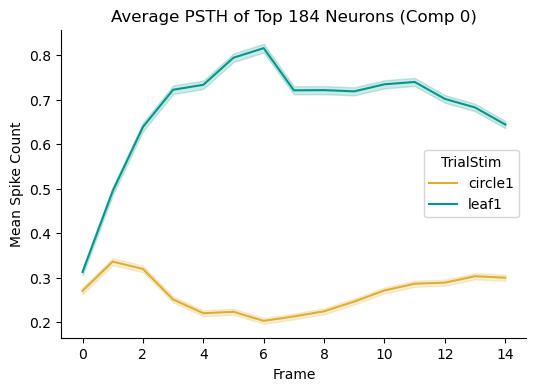

In [52]:
# 4) Quantify selectivity (AUC) and identify top neurons
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

# Define target component (1-based index, e.g. 2 for Component 2)
target_comp_idx = 0
comp_k = target_comp_idx - 1

# A) Check selectivity in W (trials)
# Re-construct trial dataframe for stats
trial_order = pivot.columns.get_level_values(1).unique().astype(int)
W = factors[2]
W_df = pd.DataFrame({'ft_trInd': trial_order, 'loading': W[:, comp_k]})
W_df['TrialStim'] = W_df['ft_trInd'].map(trial_to_stim)

# Filter for leaf/circle only
valid_trials = W_df[W_df['TrialStim'].isin(['leaf1', 'circle1'])].dropna()
group1 = valid_trials[valid_trials['TrialStim'] == 'leaf1']['loading']
group2 = valid_trials[valid_trials['TrialStim'] == 'circle1']['loading']

# AUC score (0.5 = random, 1.0 = perfect separation)
# We use loading as score; if circle is lower, we expect high AUC for leaf>circle
y_true = (valid_trials['TrialStim'] == 'leaf1').astype(int)
auc = roc_auc_score(y_true, valid_trials['loading'])
print(f"Component {target_comp_idx} Selectivity (leaf vs circle):")
print(f"  AUC = {auc:.3f}")
print(f"  Mean leaf loading: {group1.mean():.3f}, Mean circle loading: {group2.mean():.3f}")

# B) Identify top driving neurons in U
U = factors[0]
u_loadings = U[:, comp_k]
neuron_order = pivot.index.to_numpy()

# Threshold: e.g., > mean + 2*std or top 5%
thresh = np.mean(u_loadings) + 2 * np.std(u_loadings)
top_neuron_mask = u_loadings > thresh
top_neurons = neuron_order[top_neuron_mask]
print(f"\nIdentified {len(top_neurons)} top neurons driving Component {target_comp_idx} (threshold={thresh:.3f})")
print(f"Top neurons IDs: {top_neurons}")

# C) Validation Plot: PSTH of top neurons
# Filter original melted spikes for these neurons
subset_spikes = melted_spikes_start[
    melted_spikes_start['neuron'].isin(top_neurons) &
    melted_spikes_start['TrialStim'].isin(['leaf1', 'circle1'])
]

if not subset_spikes.empty:
    plt.figure(figsize=(6, 4))
    sns.lineplot(
        data=subset_spikes,
        x='frame', y='spike_value',
        hue='TrialStim',
        palette=custom_trialstim_palette,
        estimator='mean',
        errorbar='se' # standard error
    )
    plt.title(f"Average PSTH of Top {len(top_neurons)} Neurons (Comp {target_comp_idx})")
    plt.ylabel("Mean Spike Count")
    plt.xlabel("Frame")
    sns.despine()
    plt.show()
else:
    print("No spikes found for top neurons in selected conditions.")
# plt.savefig(f"results/u_loadings_by_trial_stim_comp_{target_comp_idx}.png", dpi=150)

Top selective neurons with area:


,neuron,area
0,107,V1
1,109,V1
2,119,V1
3,131,V1
4,149,V1



Counts by area:


area
V1       105
mHV       37
lHV       24
aHV       12
Other      6
Name: count, dtype: int64

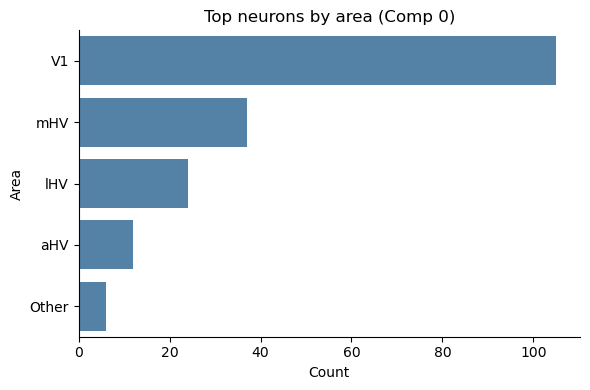

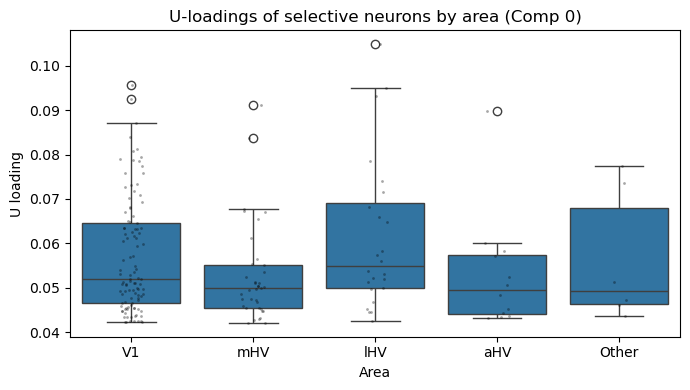

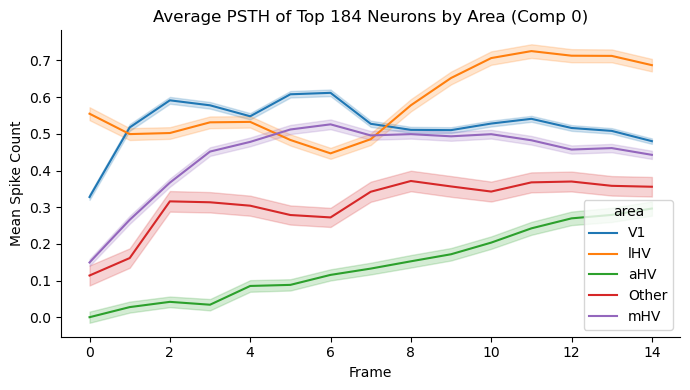

In [53]:
# Map selective neurons to area
neuron_to_area = (
    melted_spikes_start[['neuron', 'area']]
    .drop_duplicates()
    .set_index('neuron')['area']
)

# Top selective neurons with area
top_neurons_df = pd.DataFrame({'neuron': top_neurons})
top_neurons_df['area'] = top_neurons_df['neuron'].map(neuron_to_area).astype('object').fillna('Unknown')

print("Top selective neurons with area:")
display(top_neurons_df.head())
print("\nCounts by area:")
display(top_neurons_df['area'].value_counts())

# Ensure results directory exists
os.makedirs("results", exist_ok=True)

# Bar chart: counts of selective neurons by area
plt.figure(figsize=(6, 4))
area_order = top_neurons_df['area'].value_counts().index
sns.countplot(data=top_neurons_df, y='area', order=area_order, color='steelblue')
plt.title(f"Top neurons by area (Comp {target_comp_idx})")
plt.xlabel("Count")
plt.ylabel("Area")
sns.despine()
plt.tight_layout()
# plt.savefig(f"results/top_neurons_by_area_comp_{target_comp_idx}.png", dpi=150)
plt.show()

# Loadings of selective neurons by area
u_loadings_df = pd.DataFrame({'neuron': neuron_order, 'loading': u_loadings})
u_loadings_df = u_loadings_df[u_loadings_df['neuron'].isin(top_neurons_df['neuron'])].copy()
u_loadings_df['area'] = u_loadings_df['neuron'].map(neuron_to_area).astype('object').fillna('Unknown')

plt.figure(figsize=(7, 4))
sns.boxplot(data=u_loadings_df, x='area', y='loading', order=area_order)
sns.stripplot(data=u_loadings_df, x='area', y='loading', order=area_order, color='k', alpha=0.35, size=2)
plt.title(f"U-loadings of selective neurons by area (Comp {target_comp_idx})")
plt.xlabel("Area")
plt.ylabel("U loading")
plt.tight_layout()
# plt.savefig(f"results/u_loadings_by_area_comp_{target_comp_idx}.png", dpi=150)
plt.show()

# PSTH of selective neurons by area (leaf/circle only, from subset_spikes)
subset_spikes_area = subset_spikes.copy()
subset_spikes_area['area'] = subset_spikes_area['neuron'].map(neuron_to_area).astype('object').fillna('Unknown')

if not subset_spikes_area.empty:
    plt.figure(figsize=(7, 4))
    sns.lineplot(
        data=subset_spikes_area,
        x='frame', y='spike_value',
        hue='area',
        estimator='mean',
        errorbar='se'
    )
    plt.title(f"Average PSTH of Top {len(top_neurons)} Neurons by Area (Comp {target_comp_idx})")
    plt.ylabel("Mean Spike Count")
    plt.xlabel("Frame")
    sns.despine()
    plt.tight_layout()
    # plt.savefig(f"results/psth_by_area_comp_{target_comp_idx}.png", dpi=150)
    plt.show()

# Optional: save results
# top_neurons_df.to_csv(f"results/top_neurons_comp_{target_comp_idx}.csv", index=False)

Saved: results/w1_colored_by_behavior.png
Saved: results/w1_colored_by_trialstim.png
Saved: results/w1_colored_by_prev_rewarded.png

Spearman correlations with W1 (absolute magnitude sorted):
                  variable  spearman_rho   n
         run_speed_mean_15     -0.217956 201
           run_distance_15     -0.212471 201
          run_speed_max_15     -0.199093 201
              pos_delta_15     -0.157806 201
  moving_latency_frames_15      0.102848 199
          run_accel_max_15      0.041094 201
              iti_before_s           NaN 199
time_since_session_start_s           NaN 200


/Users/johnmadrid/miniconda3/envs/isp-unsupervised-learning/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/Users/johnmadrid/miniconda3/envs/isp-unsupervised-learning/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



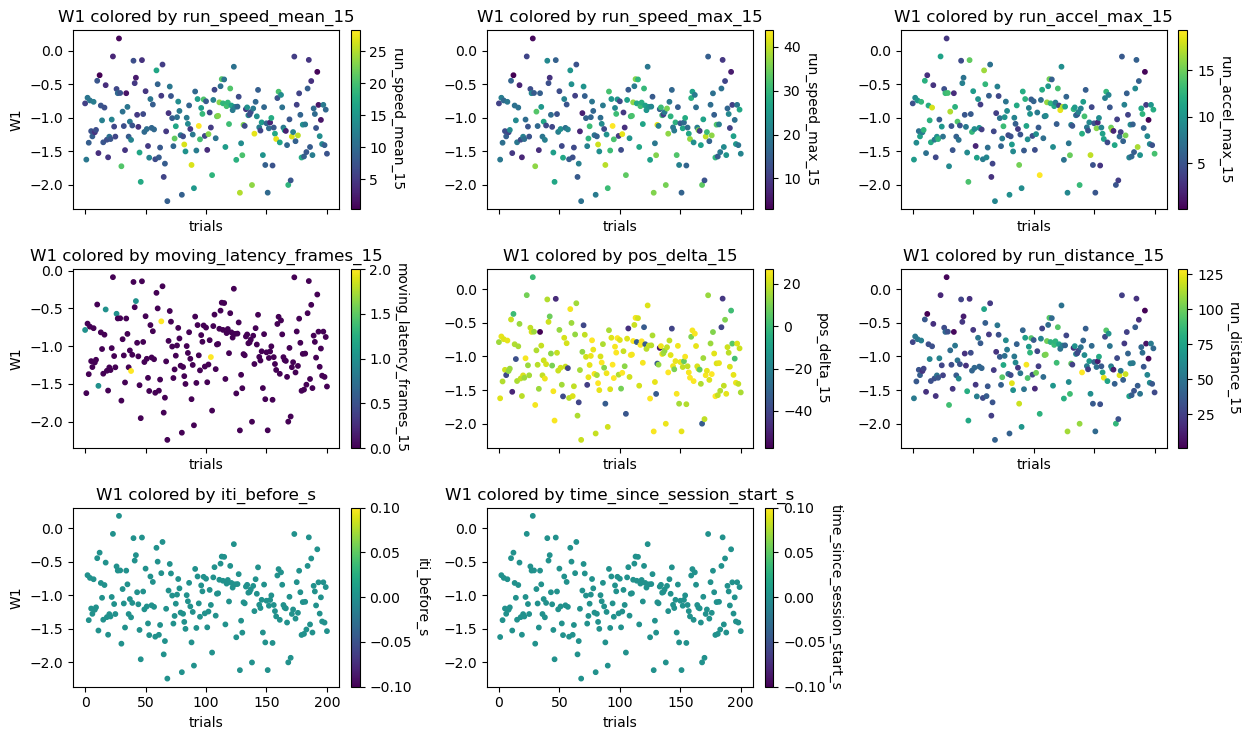

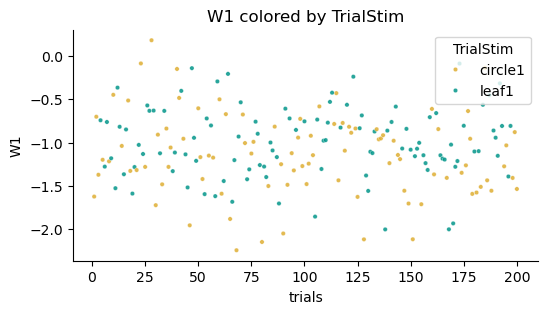

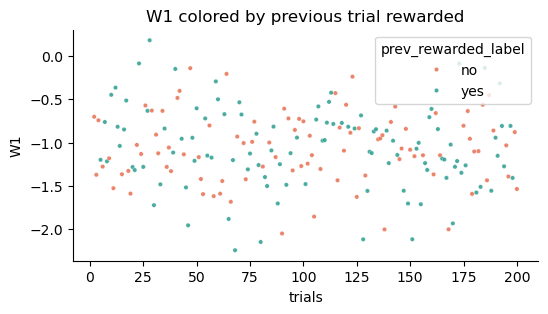

In [ ]:
# === Trial-level metrics for first 15 frames and W1 coloring ===
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Defensive checks
assert 'beh_ts_df' in globals(), 'beh_ts_df not found in the notebook scope.'
assert 'aW' in globals(), 'Factor matrix aW (trials x rank) not found.'
assert 'pivot' in globals(), 'pivot DataFrame (used to recover trial ordering) not found.'

# Recover the trial order used in the tensor
_frame_labels = pivot.columns.get_level_values(0)
_trial_labels = pivot.columns.get_level_values(1)
_trial_order = pd.unique(_trial_labels).astype(int)

# Build W1 per trial in the same order used by the tensor
w1_df = pd.DataFrame({'ft_trInd': _trial_order, 'W1': aW[:, 0]})

# Work on a copy; ensure numerics
bdf = beh_ts_df.copy()
for c in ['ft_RunSpeed', 'ft_RunCum', 'ft_Pos']:
    if c in bdf.columns:
        bdf[c] = pd.to_numeric(bdf[c], errors='coerce')

# Choose trial identifier present in behavioral dataframe
trial_id_col = 'ft_trInd' if 'ft_trInd' in bdf.columns else None
if trial_id_col is None:
    # Fallback: derive trial ids from start times
    assert 'Trial_start_time' in bdf.columns, 'Trial_start_time required to infer trial ids.'
    _starts = (
        bdf[['Trial_start_time']]
        .dropna()
        .drop_duplicates()
        .sort_values('Trial_start_time')
        .reset_index(drop=True)
    )
    _starts['ft_trInd'] = np.arange(1, len(_starts) + 1)
    bdf = bdf.merge(_starts, on='Trial_start_time', how='left')
    trial_id_col = 'ft_trInd'

# Keep only rows assigned to a trial and sort by time
bdf = bdf.dropna(subset=[trial_id_col]).copy()
bdf[trial_id_col] = bdf[trial_id_col].astype(int)
if 'ft' in bdf.columns:
    bdf = bdf.sort_values('ft')
elif 'datetime' in bdf.columns:
    bdf = bdf.sort_values('datetime')

# First-15-frame window within each trial
bdf['row_in_trial'] = bdf.groupby(trial_id_col).cumcount()
first15 = bdf[bdf['row_in_trial'] < 15].copy()

# Determine a session-specific movement threshold (robust)
speed_series = first15['ft_RunSpeed'] if 'ft_RunSpeed' in first15.columns else pd.Series(dtype=float)
if speed_series.notna().any():
    _pos_speed = speed_series[speed_series > 0]
    if _pos_speed.empty:
        speed_threshold = float(np.nanpercentile(speed_series, 20.0))
    else:
        speed_threshold = float(np.nanpercentile(_pos_speed, 20.0))
else:
    speed_threshold = 0.0

# Helper functions
_def_nan = np.nan

def _first_last_delta(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors='coerce').dropna()
    if x.empty:
        return _def_nan
    return float(x.iloc[-1] - x.iloc[0])

def _robust_diff_max(s: pd.Series) -> float:
    x = pd.to_numeric(s, errors='coerce').to_numpy()
    if x.size < 2:
        return _def_nan
    d = np.diff(x)
    if d.size == 0:
        return _def_nan
    return float(np.nanmax(d))

def _latency_to_threshold(s: pd.Series, thr: float) -> float:
    x = pd.to_numeric(s, errors='coerce').to_numpy()
    if x.size == 0:
        return _def_nan
    mask = x >= thr
    if mask.any():
        return float(np.argmax(mask))  # frame index (0..14)
    return _def_nan

# Aggregate per trial using the first-15-frame window
agg = (
    first15
    .groupby(trial_id_col, sort=True)
    .agg(
        run_speed_mean_15=('ft_RunSpeed', lambda s: float(np.nanmean(pd.to_numeric(s, errors='coerce')))),
        run_speed_max_15=('ft_RunSpeed', lambda s: float(np.nanmax(pd.to_numeric(s, errors='coerce')))),
        run_accel_max_15=('ft_RunSpeed', _robust_diff_max),
        run_distance_15=('ft_RunCum', _first_last_delta),
        pos_delta_15=('ft_Pos', _first_last_delta),
        moving_latency_frames_15=('ft_RunSpeed', lambda s: _latency_to_threshold(s, speed_threshold)),
        any_moving_15=('ft_RunSpeed', lambda s: bool((pd.to_numeric(s, errors='coerce') >= speed_threshold).any())),
    )
    .reset_index()
    .rename(columns={trial_id_col: 'ft_trInd'})
)

# Bring in trial-level metadata for ITI, reward history, and time since start
trial_features = agg.copy()
if 'beh_trialinfo_df' in globals():
    tif = beh_trialinfo_df.copy()
    if 'ft_trInd' not in tif.columns and 'Trial_start_time' in tif.columns:
        _u = (
            tif[['Trial_start_time']]
            .dropna()
            .drop_duplicates()
            .sort_values('Trial_start_time')
            .reset_index(drop=True)
        )
        _u['ft_trInd'] = np.arange(1, len(_u) + 1)
        tif = tif.merge(_u, on='Trial_start_time', how='left')
    keep_cols = [c for c in ['ft_trInd', 'TrialStim', 'Trial_start_time', 'Trial_end_time'] if c in tif.columns]
    tif = tif[keep_cols].drop_duplicates(subset=['ft_trInd']) if 'ft_trInd' in keep_cols else tif
    if 'ft_trInd' in tif.columns:
        tif = tif.sort_values('ft_trInd')
        if 'Trial_start_time' in tif.columns:
            try:
                ts = pd.to_datetime(tif['Trial_start_time'])
                te = pd.to_datetime(tif['Trial_end_time']) if 'Trial_end_time' in tif.columns else None
                tif['time_since_session_start_s'] = (ts - ts.iloc[0]).dt.total_seconds()
                if te is not None:
                    tif['iti_before_s'] = (ts - te.shift(1)).dt.total_seconds()
            except Exception:
                ts = pd.to_numeric(tif['Trial_start_time'], errors='coerce')
                tif['time_since_session_start_s'] = ts - ts.iloc[0]
                if 'Trial_end_time' in tif.columns:
                    te = pd.to_numeric(tif['Trial_end_time'], errors='coerce')
                    tif['iti_before_s'] = ts - te.shift(1)
        # Trial history features
        if 'TrialStim' in tif.columns:
            tif['prev_TrialStim'] = tif['TrialStim'].shift(1)
        # Rewarded flag: use an explicit reward column if present; otherwise derive from TrialStim == leaf
        reward_cols = ['Rewarded', 'rewarded', 'Reward', 'RewardOutcome', 'DeliveredReward', 'WaterReward', 'reward']
        reward_col = next((c for c in reward_cols if c in tif.columns), None)
        if reward_col is not None:
            sv = pd.to_numeric(tif[reward_col], errors='coerce')
            if sv.notna().any():
                tif['rewarded'] = (sv > 0).astype(bool)
            else:
                st = tif[reward_col].astype(str).str.strip().str.lower()
                tif['rewarded'] = st.isin(['1', 'true', 'yes', 'y', 't'])
        elif 'TrialStim' in tif.columns:
            tif['rewarded'] = tif['TrialStim'].astype(str).str.contains('leaf', case=False, na=False)
        else:
            tif['rewarded'] = np.nan
        tif['prev_rewarded'] = tif['rewarded'].shift(1)
        # Label previous reward without mixing string and float types
        tif['prev_rewarded_label'] = tif['prev_rewarded'].map({True: 'yes', False: 'no'})
        trial_features = trial_features.merge(tif, on='ft_trInd', how='left')

# Join with W1
w1_joined = w1_df.merge(trial_features, on='ft_trInd', how='left').sort_values('ft_trInd')

# Plots: W1 colored by candidate continuous variables
selected_vars = [
    'run_speed_mean_15',
    'run_speed_max_15',
    'run_accel_max_15',
    'moving_latency_frames_15',
    'pos_delta_15',
    'run_distance_15',
    'iti_before_s',
    'time_since_session_start_s',
]
existing_vars = [v for v in selected_vars if v in w1_joined.columns]

n = len(existing_vars)
cols = 3
rows = int(np.ceil(n / cols)) if n > 0 else 1
fig, axes = plt.subplots(rows, cols, figsize=(4.2 * cols, 2.5 * rows), squeeze=False, sharex=True)
for idx, var in enumerate(existing_vars):
    ax = axes[idx // cols, idx % cols]
    sc = ax.scatter(w1_joined['ft_trInd'], w1_joined['W1'], c=w1_joined[var], cmap='viridis', s=10)
    ax.set_title(f'W1 colored by {var}')
    ax.set_xlabel('trials')
    if idx % cols == 0:
        ax.set_ylabel('W1')
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(var, rotation=270, labelpad=12)
for j in range(n, rows * cols):
    axes[j // cols, j % cols].axis('off')
plt.tight_layout()
os.makedirs('results', exist_ok=True)
_out1 = os.path.join('results', 'w1_colored_by_behavior.png')
# fig.savefig(_out1, dpi=150)
print(f'Saved: {_out1}')

# Additional panel for TrialStim (categorical), if available
if 'TrialStim' in w1_joined.columns:
    fig2, ax2 = plt.subplots(1, 1, figsize=(6, 3))
    _palette = {'circle1': '#DFAE32', 'leaf1': '#02968a'}
    sns.scatterplot(data=w1_joined, x='ft_trInd', y='W1', hue='TrialStim', s=10, alpha=0.85, palette=_palette, ax=ax2)
    ax2.set_title('W1 colored by TrialStim')
    ax2.set_xlabel('trials')
    ax2.set_ylabel('W1')
    sns.despine(ax=ax2, top=True, right=True)
    _out2 = os.path.join('results', 'w1_colored_by_trialstim.png')
    # fig2.savefig(_out2, dpi=150)
    print(f'Saved: {_out2}')

# Additional panel for previous trial rewarded (categorical)
if 'prev_rewarded_label' in w1_joined.columns:
    fig3, ax3 = plt.subplots(1, 1, figsize=(6, 3))
    _palette2 = {'yes': '#2A9D8F', 'no': '#E76F51'}
    sns.scatterplot(data=w1_joined, x='ft_trInd', y='W1', hue='prev_rewarded_label', s=10, alpha=0.85, palette=_palette2, ax=ax3)
    ax3.set_title('W1 colored by previous trial rewarded')
    ax3.set_xlabel('trials')
    ax3.set_ylabel('W1')
    sns.despine(ax=ax3, top=True, right=True)
    _out3 = os.path.join('results', 'w1_colored_by_prev_rewarded.png')
    # fig3.savefig(_out3, dpi=150)
    print(f'Saved: {_out3}')

# Spearman correlations (rank-based) between W1 and continuous variables
corr_rows = []
for var in existing_vars:
    x = w1_joined[var]
    y = w1_joined['W1']
    mask = x.notna() & y.notna()
    if mask.sum() >= 5:
        rho = x.rank().corr(y.rank(), method='pearson')
        corr_rows.append((var, float(rho), int(mask.sum())))
if corr_rows:
    corr_df = pd.DataFrame(corr_rows, columns=['variable', 'spearman_rho', 'n']).sort_values('spearman_rho', key=lambda s: s.abs(), ascending=False)
    print('\nSpearman correlations with W1 (absolute magnitude sorted):')
    print(corr_df.to_string(index=False))
else:
    print('No valid correlations computed for W1 with the selected variables.')
